<a href="https://colab.research.google.com/github/Nobskay/Nobskay/blob/main/forecasting%2Bshock%20generatr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Cara* kerja :
1. Data Load
2. Data Clean
3. Data Display
4. Prediksi variabel Eksogen dengan VAR (1)
5. SARIMAX menggunakan data prediksi VAR
6. Display All result (Base predict + Matrik Evaluasi)
7. Shock input - Shock output
8. Summary

Install

In [ ]:
!pip install xlsxwriter reportlab
!pip install statsmodels pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.4 MB/s eta 0:00:00


#DATA LOAD (pilih salah 1)

In [ ]:
import pandas as pd

# Link Google Sheets
url = "https://docs.google.com/spreadsheets/d/1ZgupCzBFetLiRO5Ir_E_fCNC3oP5W9jU0rMJ6UIjh6k/edit?gid=0"

# Ubah jadi link export CS
url = url.replace("/edit", "/export") + "&format=csv"

# Baca datanya
df = pd.read_csv(url, parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date").asfreq("MS")
df.head()


,gdpgr,pconsump,inflation,unemploy,short-term,long-term,aa10y,gdpinv,recession,GIDN1YR,GIDN2YR,GIDN3YR,GIDN5YR,GIDN7YR,GIDN10YR,GIDN20YR
Date,,,,,,,,,,,,,,,,
2015-10-01,-0.69,1.64,1.50,5.94,7.50,8.25,-,2.82,-,7.06,7.64,7.75,8.01,8.16,8.25,8.83
2015-11-01,-0.70,1.62,2.46,5.97,7.50,8.20,-,2.82,-,7.05,7.58,7.78,8.09,8.19,8.27,8.83
2015-12-01,-0.70,1.59,-0.24,6.01,7.50,8.25,-,2.82,-,7.03,7.55,7.78,7.98,8.12,8.14,8.60
2016-01-01,-0.05,0.30,-0.36,6.04,7.50,7.89,-,2.82,-,6.75,7.38,7.62,7.73,7.86,7.82,8.25
2016-02-01,-0.05,0.30,0.17,6.08,7.75,7.99,-,2.82,-,7.04,7.63,7.76,7.93,8.05,8.05,8.47


In [ ]:
#Data dari url drive
import pandas as pd


url = 'https://drive.google.com/file/d/1EwVWVHjPQSwnx39p8OtKDmNsWcBlFeE0/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url, parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date").asfreq("MS")  # MS = Month Start
df.head()

,DPK_IDR_billion,Loan_IDR_billion,NIM,NPL,CAR,LDR,ROA,inflation_CPI_pct,BI_rate_pct,USD_IDR,GDP_growth_annual_pct,unemployment_rate_pct,commodity_index,IHSG,bond_yield_10y_pct,OPEX_IDR_billion,fee_income_IDR_billion,provisioning_IDR_billion
Date,,,,,,,,,,,,,,,,,,
2015-01-01,103455.09,69041.56,3.096,1.936,22.731,66.736,1.188,3.099,5.015,13253,4.848,5.452,93.32,4375,5.967,2020.03,287.09,225.68
2015-02-01,102187.61,68812.22,3.203,2.440,24.012,67.339,1.307,3.472,4.791,12978,5.030,5.251,108.54,5028,6.279,2090.12,312.84,178.57
2015-03-01,102437.98,73895.95,3.460,2.407,22.770,72.137,1.417,3.996,4.267,13301,5.068,5.135,102.76,4933,6.674,2318.80,394.86,151.76
2015-04-01,103184.94,73305.28,3.654,2.132,23.346,71.043,1.389,4.305,4.010,13414,5.478,5.151,98.07,4735,6.337,2432.48,375.87,71.39
2015-05-01,104218.93,70794.41,4.070,2.365,24.240,67.929,1.369,3.819,3.341,13067,5.396,4.850,103.22,4949,6.507,2220.67,375.71,217.91


In [ ]:
import pandas as pd
from google.colab import files

# User upload file CSV
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load data
df = pd.read_csv(filename, parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date").asfreq("MS")  # Monthly Start
df.head()


Saving Data Makroekonomi dan Asset di Indonesia - format csv.csv to Data Makroekonomi dan Asset di Indonesia - format csv.csv


ValueError: Missing column provided to 'parse_dates': 'Date'

#DATA CLEANING

In [ ]:
import numpy as np

# Coerce non-numeric to numeric where possible
for c in df.columns:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = pd.to_numeric(df[c], errors="coerce")

audit = (df
         .agg(["count","nunique","min","mean","max","std"])
         .T
         .assign(missing=lambda x: len(df)-x["count"],
                 missing_pct=lambda x: 100*(len(df)-x["count"])/len(df)))
audit


,count,nunique,min,mean,max,std,missing,missing_pct
gdpgr,101.0,52.0,-1.44,0.298020,1.68,0.824064,0.0,0.000000
pconsump,101.0,48.0,-2.25,0.591287,1.64,0.652858,0.0,0.000000
inflation,101.0,71.0,-24.98,0.038416,2.46,2.545397,0.0,0.000000
unemploy,100.0,72.0,4.88,5.787700,7.80,0.619623,1.0,0.990099
short-term,101.0,17.0,3.50,5.195545,7.75,1.402500,0.0,0.000000
long-term,101.0,86.0,6.06,7.324356,9.39,0.756373,0.0,0.000000
aa10y,0.0,0.0,NaN,NaN,NaN,NaN,101.0,100.000000
gdpinv,101.0,8.0,0.49,1.840990,2.82,0.561137,0.0,0.000000
recession,6.0,1.0,1.00,1.000000,1.00,0.000000,95.0,94.059406
GIDN1YR,101.0,91.0,2.93,5.695248,8.14,1.366052,0.0,0.000000


In [ ]:
# Pastikan kalender bulanan penuh (kalau ada bulan hilang)
full_idx = pd.date_range(df.index.min(), df.index.max(), freq="MS")
df = df.reindex(full_idx)

# Interpolasi time-based, lalu ffill/bfill untuk ujung-ujung
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
df[num_cols] = df[num_cols].interpolate(method="time", limit_direction="both").ffill().bfill()


In [ ]:
def winsorize_series(s, low_q=0.01, high_q=0.99):
    lo, hi = s.quantile(low_q), s.quantile(high_q)
    return s.clip(lower=lo, upper=hi)

df[num_cols] = df[num_cols].apply(winsorize_series)


In [ ]:
df.to_csv("timeseries_clean.csv", date_format="%Y-%m-%d")
print("Saved -> timeseries_clean.csv")
# === Save Clean with explicit 'Date' column ===
# Asumsi: df adalah DataFrame hasil cleaning dengan DatetimeIndex bulanan
out = df.copy().sort_index().asfreq("MS")

# jadikan tanggal sebagai kolom dan beri nama 'Date'
out = out.reset_index().rename(columns={"index": "Date"})

# (opsional) simpan format tanggal yang konsisten
# out["Date"] = out["Date"].dt.strftime("%Y-%m-%d")

# simpan TANPA index — sehingga CSV punya kolom 'Date'
out.to_csv("timeseries_clean.csv", index=False)
print("Saved -> timeseries_clean.csv (dengan kolom 'Date')")


Saved -> timeseries_clean.csv
Saved -> timeseries_clean.csv (dengan kolom 'Date')


#DATA DISPLAY

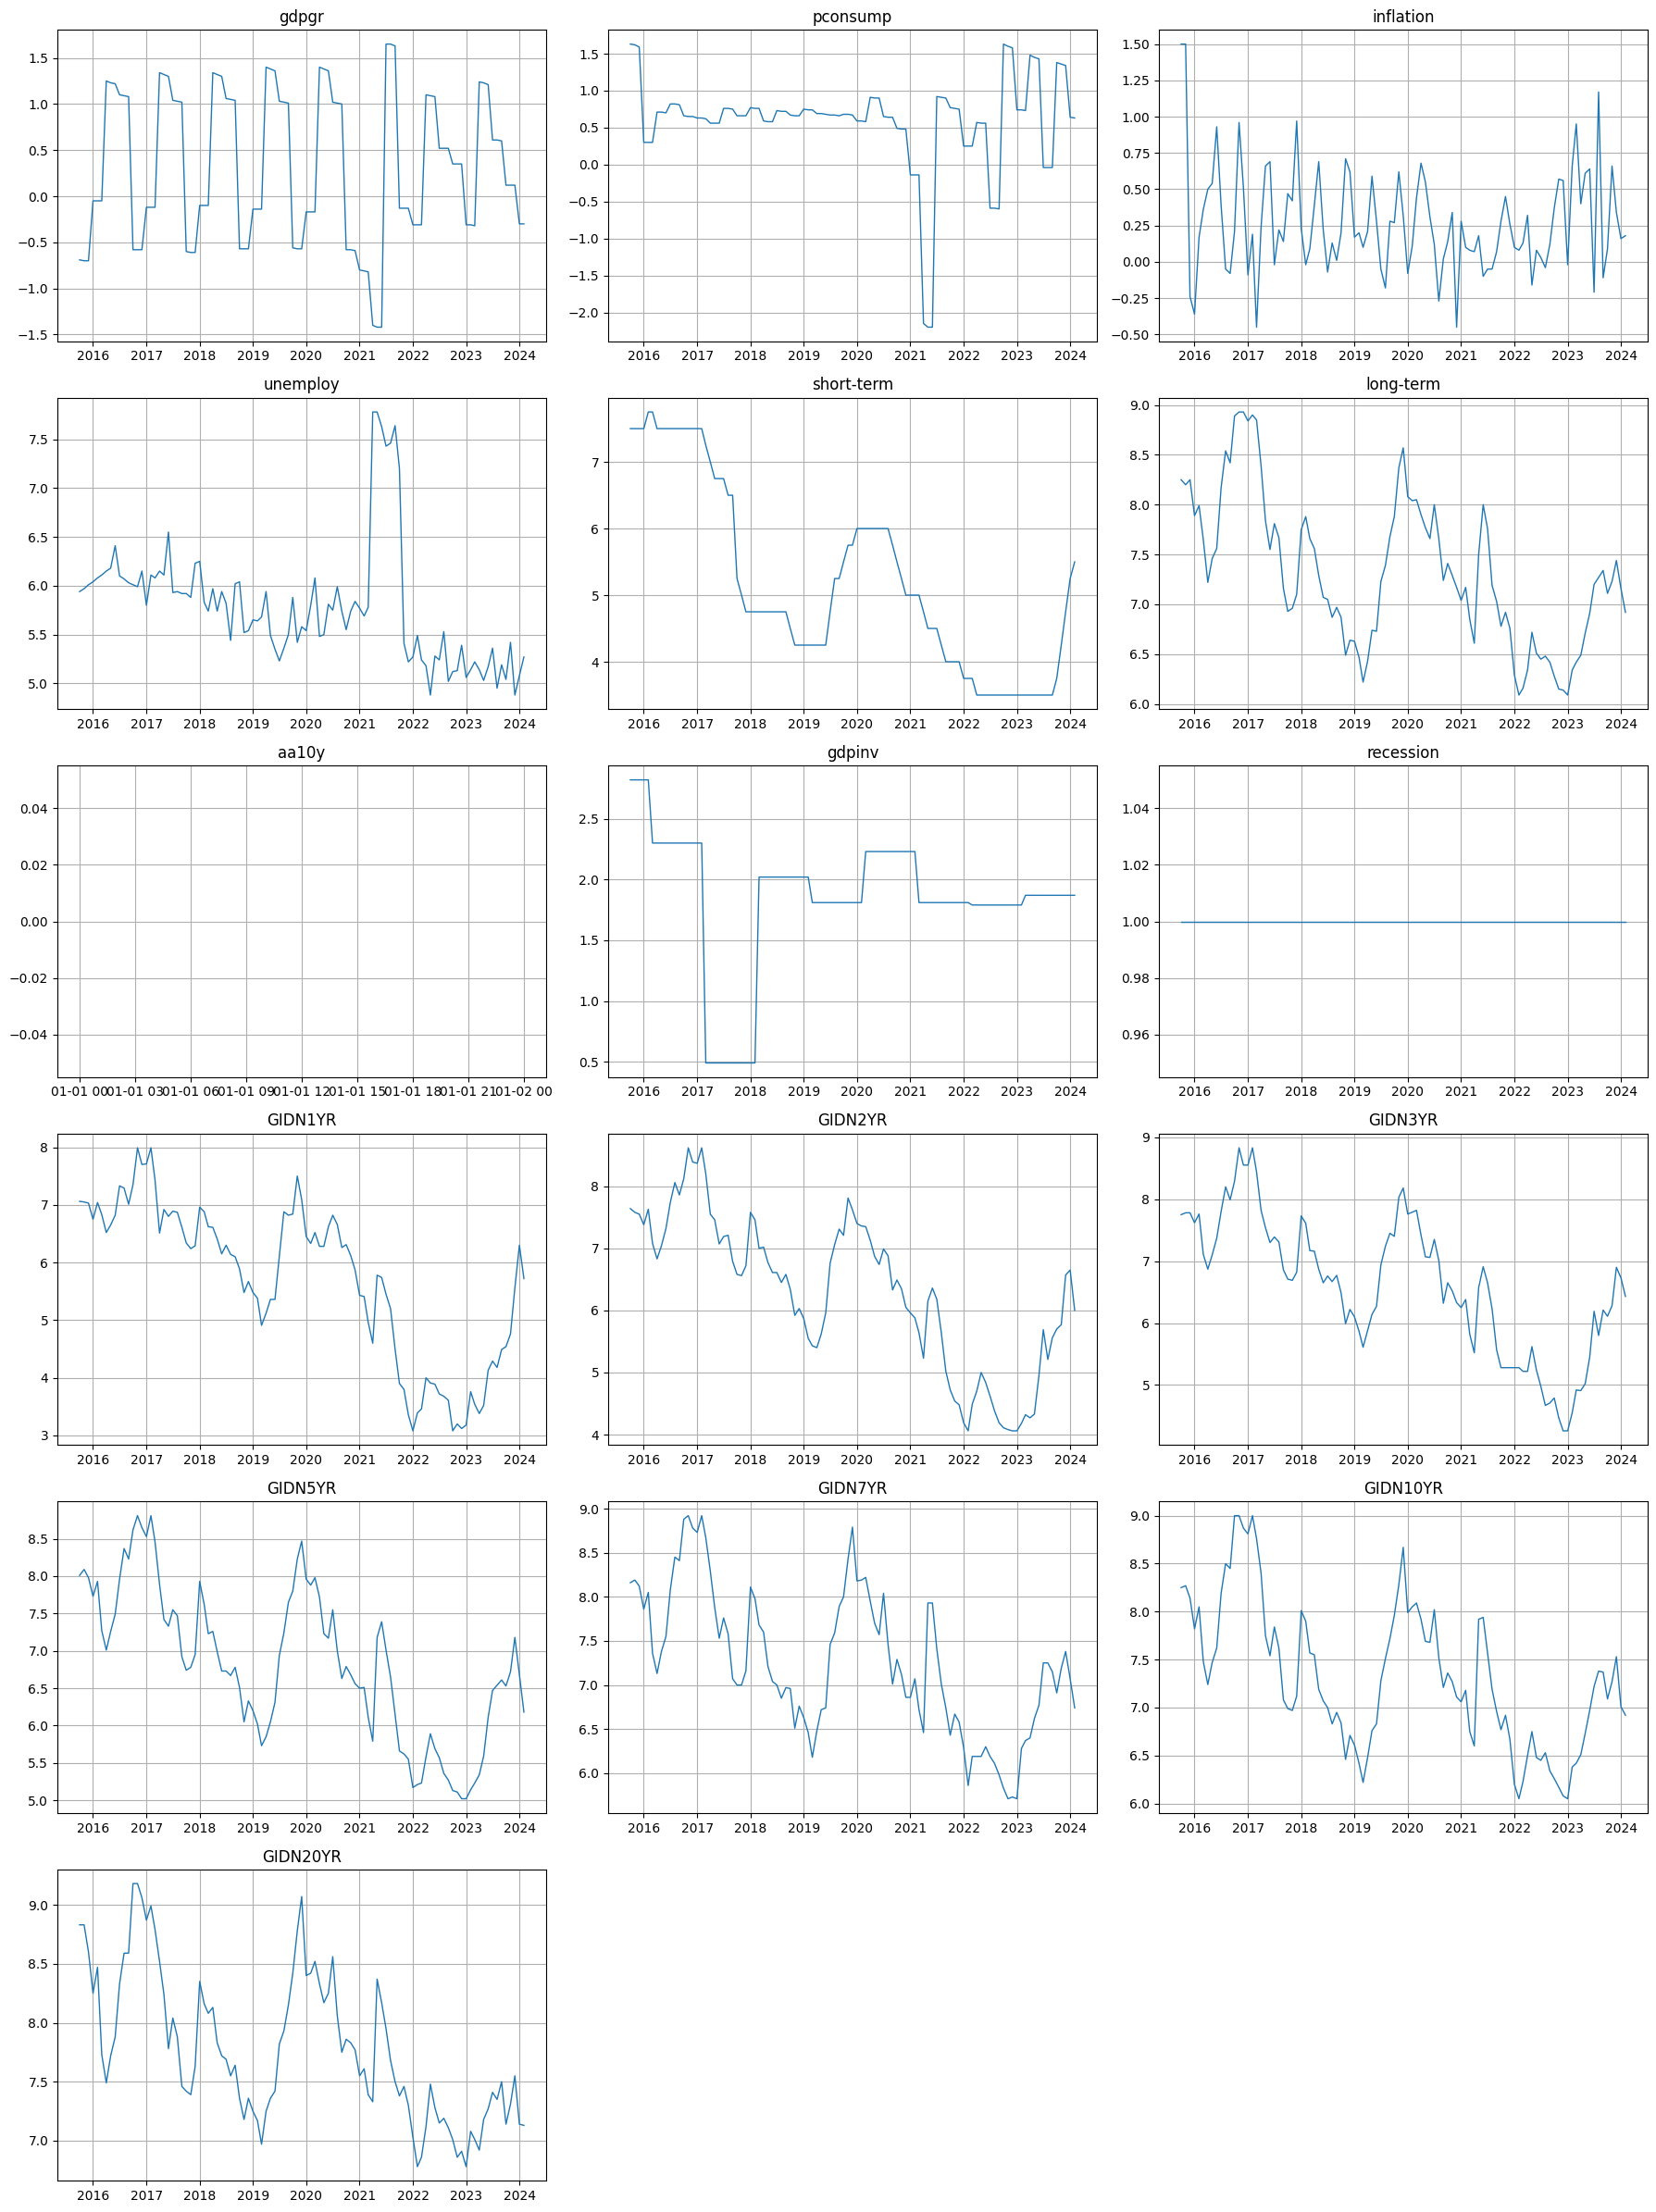

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# path file CSV
CSV_PATH = Path("/content/timeseries_clean.csv")

# baca data
df = pd.read_csv(CSV_PATH)

# gunakan kolom 'Unnamed: 0' sebagai tanggal
df = df.rename(columns={"Unnamed: 0": "Date"})
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

# --- MULTI-PLOT semua kolom numerik ---
num_cols = df.select_dtypes(include="number").columns.tolist()

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))
for i, col in enumerate(num_cols, start=1):
    ax = plt.subplot(n_rows, n_cols, i)
    ax.plot(df.index, df[col], linewidth=1)
    ax.set_title(col)
    ax.grid(True)

plt.tight_layout()
plt.show()

# --- Statistik deskriptif per kolom ---
def descriptive_stats(frame: pd.DataFrame) -> pd.DataFrame:
    desc = frame.describe(percentiles=[0.25, 0.5, 0.75]).T.rename(
        columns={"25%": "p25", "50%": "median", "75%": "p75"}
    )
    desc["missing"] = frame.isna().sum()
    cols = ["count", "missing", "mean", "std", "min", "p25", "median", "p75", "max"]
    return desc[cols]

# contoh pakai:
# stats = descriptive_stats(df[num_cols])
# print(stats.round(3))


#Pilih Target dan EXOG

In [ ]:
# ===== Flexible column picker (multi-target & multi-exog) =====
from pathlib import Path
import pandas as pd

OUT_DIR = Path("/content/data")
CSV_PATH = Path("/content/timeseries_clean.csv")

def _print_columns(cols, date_idx=0):
    print("\n== Header kolom dari CSV ==")
    print("(pakai index atau nama kolom; pisahkan dengan koma/spasi)")
    for i, c in enumerate(cols):
        tag = " [DATE]" if i == date_idx else ""
        print(f"{i:>3} : {c}{tag}")

def _parse_selection(raw, cols):
    """
    Terima input: "1 2 5" atau "NIM, NPL" atau campuran.
    Return: list nama kolom yang valid (unik, urut sesuai kemunculan).
    """
    if not raw:
        return []
    idx_set, name_set = [], []
    tokens = [t.strip() for t in raw.replace(",", " ").split() if t.strip()]
    for t in tokens:
        if t.isdigit():
            k = int(t)
            if 0 <= k < len(cols):
                idx_set.append(cols[k])
            continue
        if t in cols:
            name_set.append(t)
    seen, out = set(), []
    for c in idx_set + name_set:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out

def pick_columns(csv_path: Path, numeric_only_for=("target","exog")):
    """
    numeric_only_for:
        - gunakan {"target","exog"} untuk menyaring hanya kolom numerik bagi target/exog
        - gunakan set() jika tidak ingin penyaringan numerik
    """
    # baca sample untuk deteksi tipe
    df_head = pd.read_csv(csv_path, nrows=200)
    all_cols = df_head.columns.tolist()
    if not all_cols:
        raise ValueError("CSV tidak memiliki kolom.")
    # TANGGAL = KOLOM 0 (pasti)
    DATE_COL = all_cols[0]

    _print_columns(all_cols, date_idx=0)

    # Kandidat numerik (opsional)
    num_cols = df_head.select_dtypes(include="number").columns.tolist()

    # TARGETS (boleh banyak) - cegah memilih kolom tanggal
    tgt_raw = input("Pilih TARGETS (banyak): ").strip()
    TARGETS = [c for c in _parse_selection(tgt_raw, all_cols) if c != DATE_COL]
    if "target" in set(numeric_only_for):
        TARGETS = [c for c in TARGETS if c in num_cols]

    # EXOG (boleh banyak) - singkirkan tanggal & bentrok dengan targets
    exog_raw = input("Pilih EXOG_COLS (banyak): ").strip()
    EXOG_COLS = [c for c in _parse_selection(exog_raw, all_cols) if c != DATE_COL]
    if "exog" in set(numeric_only_for):
        EXOG_COLS = [c for c in EXOG_COLS if c in num_cols]
    # Bersihkan bentrok
    deny = set(TARGETS + [DATE_COL])
    EXOG_COLS = [c for c in EXOG_COLS if c not in deny]

    # Ringkasan
    print("\n== Ringkasan Pilihan ==")
    print("DATE_COL   :", DATE_COL)
    print("TARGETS    :", TARGETS if TARGETS else "(kosong)")
    print("EXOG_COLS  :", EXOG_COLS if EXOG_COLS else "(kosong)")

    # Siapkan df final: parse tanggal & set index
    df = pd.read_csv(csv_path)
    # pastikan kolom 0 ada di df dan parse sebagai datetime
    if DATE_COL not in df.columns:
        raise KeyError(f"Kolom tanggal '{DATE_COL}' tidak ditemukan pada CSV.")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    if df[DATE_COL].isna().all():
        raise ValueError(f"Kolom tanggal '{DATE_COL}' gagal diparse ke datetime. Cek format tanggal di CSV.")
    df = df.set_index(DATE_COL).sort_index()

    # Subset Y & X (bisa None kalau kosong)
    y_df = df[TARGETS] if TARGETS else None
    X    = df[EXOG_COLS] if EXOG_COLS else None

    # Validasi ringan
    if y_df is not None and y_df.empty:
        print("Peringatan: TARGETS menghasilkan dataframe kosong.")
    if X is not None and X.empty:
        print("Peringatan: EXOG_COLS menghasilkan dataframe kosong.")

    return DATE_COL, TARGETS, EXOG_COLS, y_df, X

# ===== Pakai di kode kamu =====
# (Akan menampilkan header & prompt memilih kolom)
DATE_COL, TARGETS, EXOG_COLS, y_df, X = pick_columns(CSV_PATH)



== Header kolom dari CSV ==
(pakai index atau nama kolom; pisahkan dengan koma/spasi)
  0 : Date [DATE]
  1 : gdpgr
  2 : pconsump
  3 : inflation
  4 : unemploy
  5 : short-term
  6 : long-term
  7 : aa10y
  8 : gdpinv
  9 : recession
 10 : GIDN1YR
 11 : GIDN2YR
 12 : GIDN3YR
 13 : GIDN5YR
 14 : GIDN7YR
 15 : GIDN10YR
 16 : GIDN20YR
Pilih TARGETS (banyak): 10 11 12 13 14 15 16
Pilih EXOG_COLS (banyak): 1 2 3 4 5 6 8

== Ringkasan Pilihan ==
DATE_COL   : Date
TARGETS    : ['GIDN1YR', 'GIDN2YR', 'GIDN3YR', 'GIDN5YR', 'GIDN7YR', 'GIDN10YR', 'GIDN20YR']
EXOG_COLS  : ['gdpgr', 'pconsump', 'inflation', 'unemploy', 'short-term', 'long-term', 'gdpinv']


#Prediksi Eksogen (VAR)

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from statsmodels.tsa.api import VAR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
# ===== Cell 1 — IMPORTS & CONFIG =====
import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.tsa.api import VAR


# Path data bank (historis makro + KPI bank)
CSV_PATH = Path("/content/timeseries_clean.csv")



# Parameter simulasi
HORIZON     = 60     # 60 bulan ke depan
N_SIM       = 1000   # jumlah simulasi Monte Carlo
RANDOM_SEED = 0      # untuk reprodusibilitas

# Output files
VAR_CSV_PATH      = Path("/content/data/var.csv")
VAR_CHOL_CSV_PATH = Path("/content/data/var1chol.csv")  # cholesky σ_u
X_MEAN_CSV        = Path("/content/data/X_future_mean.csv")
X_P10_CSV         = Path("/content/data/X_future_p10.csv")
X_P90_CSV         = Path("/content/data/X_future_p90.csv")
X_P25_CSV         = Path("/content/data/X_future_p25.csv")
X_P75_CSV         = Path("/content/data/X_future_p75.csv")
X_PMAX_CSV        = Path("/content/data/X_future_pmax.csv")
X_PMIN_CSV        = Path("/content/data/X_future_pmin.csv")


In [ ]:
# ===== Cell 2 — LOAD & PREP  =====
raw = pd.read_csv(CSV_PATH)

# Rename 'Unnamed: 0' → 'Date' jika ada
if "Unnamed: 0" in raw.columns and "Date" not in raw.columns:
    raw = raw.rename(columns={"Unnamed: 0": "Date"})

# Pastikan kolom Date ada
if "Date" not in raw.columns:
    raise ValueError(f"Tidak menemukan kolom tanggal. Kolom tersedia: {list(raw.columns)}")

# Konversi ke datetime & set index
raw["Date"] = pd.to_datetime(raw["Date"])
df = raw.set_index("Date").sort_index()

# Selaraskan ke MonthEnd (
df.index = df.index.to_period("M").to_timestamp("M")

# Ambil hanya kolom numerik
df = df.apply(pd.to_numeric, errors="coerce")

# Validasi exog
missing = [c for c in EXOG_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Kolom exogenous hilang: {missing}\nKolom tersedia: {list(df.columns)}")

X_hist = df[EXOG_COLS].dropna().copy()
display(X_hist.tail())


,gdpgr,pconsump,inflation,unemploy,short-term,long-term,gdpinv
Date,,,,,,,
2023-10-31,0.12,1.38,0.09,5.04,3.75,7.11,1.87
2023-11-30,0.12,1.36,0.66,5.42,4.25,7.23,1.87
2023-12-31,0.12,1.34,0.34,4.88,4.75,7.44,1.87
2024-01-31,-0.30,0.64,0.16,5.08,5.25,7.16,1.87
2024-02-29,-0.30,0.63,0.18,5.27,5.50,6.92,1.87


In [ ]:
# ===== Cell 3 — FIT VAR(1) & SIMPAN var.csv + var1chol.csv (versi revisi) =====
from pathlib import Path
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

# Pastikan folder output ada
OUT_DIR = Path("/content/data")   # bisa ganti ke Path("/mnt/data") di Colab
OUT_DIR.mkdir(parents=True, exist_ok=True)

VAR_CSV_PATH      = OUT_DIR / "var.csv"
VAR_CHOL_CSV_PATH = OUT_DIR / "var1chol.csv"

# --- Fit VAR(1) ---
var_res = VAR(X_hist).fit(1)

# Ekstrak parameter VAR(1): y_t = c + Phi * y_{t-1} + e_t
Phi = var_res.coefs[0]       # matriks koefisien (k×k)
c   = var_res.intercept      # konstanta (k,)
Su  = var_res.sigma_u        # kovarians error (k×k)

# --- Simpan var.csv ---
# isi: koef VAR, konstanta, residual std dev
var_df = pd.DataFrame(Phi, columns=EXOG_COLS, index=EXOG_COLS)
var_df["const"]    = c
var_df["residual"] = np.sqrt(np.diag(Su))

# reset_index(drop=True) →
var_df.reset_index(drop=True).to_csv(VAR_CSV_PATH, index=False)

# --- Pastikan covariance PD sebelum Cholesky ---
def make_positive_definite(mat, eps=1e-10):
    try:
        np.linalg.cholesky(mat)
        return mat
    except np.linalg.LinAlgError:
        return mat + np.eye(mat.shape[0]) * eps

Su_pd = make_positive_definite(Su)
L     = np.linalg.cholesky(Su_pd)

# --- Simpan var1chol.csv ---
pd.DataFrame(L, columns=EXOG_COLS, index=EXOG_COLS) \
  .reset_index(drop=True) \
  .to_csv(VAR_CHOL_CSV_PATH, index=False)

print(f"[OK] Saved VAR(1) parameters to {VAR_CSV_PATH} and {VAR_CHOL_CSV_PATH}")


[OK] Saved VAR(1) parameters to /content/data/var.csv and /content/data/var1chol.csv


In [ ]:
# ===== Cell 4 — MONTE CARLO (n_sim, horizon) + OUTPUT =====
import numpy as np
import pandas as pd
from pathlib import Path

# Pastikan variabel dari cell sebelumnya sudah ada:
# - OUT_DIR, EXOG_COLS, X_hist
# - Phi (k×k), c (k,), L (Cholesky dari sigma_u)
# - HORIZON, N_SIM

OUT_DIR.mkdir(parents=True, exist_ok=True)

# RNG untuk reprodusibilitas (opsional: set seed di sini)
RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

k = len(EXOG_COLS)
last_y = X_hist.iloc[-1].to_numpy(dtype=float)   # y_{t-1} awal
dates_f = pd.date_range(X_hist.index[-1] + pd.offsets.MonthEnd(1),
                        periods=HORIZON, freq="ME")

# sims shape = (N_SIM, HORIZON, k)
sims = np.empty((N_SIM, HORIZON, k), dtype=float)

for s in range(N_SIM):
    y_prev = last_y.copy()
    for t in range(HORIZON):
        # shock ~ N(0, Σ_u) via Cholesky
        z = rng.standard_normal(k)   # ~ N(0, I)
        e = L @ z                    # ~ N(0, Σ_u)
        # VAR(1): y_t = c + Phi y_{t-1} + e_t
        y_new = c + Phi @ y_prev + e
        sims[s, t, :] = y_new
        y_prev = y_new

# Summary statistics across simulations
mean_path = sims.mean(axis=0)               # (H, k)
p10_path  = np.percentile(sims, 10, axis=0) # (H, k)
p25_path  = np.percentile(sims, 25, axis=0) # (H, k)
p75_path  = np.percentile(sims, 75, axis=0) # (H, k)
p90_path  = np.percentile(sims, 90, axis=0) # (H, k)
pmax_path  = np.percentile(sims, 100, axis=0) # (H, k)
pmin_path  = np.percentile(sims, 0, axis=0) # (H, k)

X_future_mean = pd.DataFrame(mean_path, index=dates_f, columns=EXOG_COLS)
X_future_p10  = pd.DataFrame(p10_path,  index=dates_f, columns=EXOG_COLS)
X_future_p25  = pd.DataFrame(p25_path,  index=dates_f, columns=EXOG_COLS)
X_future_p75  = pd.DataFrame(p75_path,  index=dates_f, columns=EXOG_COLS)
X_future_p90  = pd.DataFrame(p90_path,  index=dates_f, columns=EXOG_COLS)
X_future_pmax = pd.DataFrame(pmax_path,  index=dates_f, columns=EXOG_COLS)
X_future_pmin   = pd.DataFrame(pmin_path,  index=dates_f, columns=EXOG_COLS)

print("[OK] VAR(1)+Monte Carlo selesai.")
print(f"HORIZON={HORIZON}, N_SIM={N_SIM}, k={k}")
print("\n[INFO] X_future_mean (head):")
print(X_future_mean.head())

# --- Simpan hasil ---
X_MEAN_CSV = OUT_DIR / "X_future_mean.csv"
X_P10_CSV  = OUT_DIR / "X_future_p10.csv"
X_P25_CSV  = OUT_DIR / "X_future_p25.csv"
X_P75_CSV  = OUT_DIR / "X_future_p75.csv"
X_P90_CSV  = OUT_DIR / "X_future_p90.csv"
X_PMAX_CSV  = OUT_DIR / "X_future_pmax.csv"
X_PMIN_CSV  = OUT_DIR / "X_future_pmin.csv"

X_future_mean.to_csv(X_MEAN_CSV)
X_future_p10.to_csv(X_P10_CSV)
X_future_p90.to_csv(X_P90_CSV)
X_future_p25.to_csv(X_P25_CSV)
X_future_p75.to_csv(X_P75_CSV)
X_future_pmax.to_csv(X_PMAX_CSV)
X_future_pmin.to_csv(X_PMIN_CSV)

print("Saved:", X_MEAN_CSV, X_P10_CSV, X_P90_CSV, X_P75_CSV, X_P25_CSV, X_PMAX_CSV, X_PMIN_CSV)

# (Opsional) ambil satu jalur simulasi untuk skenario spesifik:
# sample_path = pd.DataFrame(sims[0], index=dates_f, columns=EXOG_COLS)
# sample_path.to_csv(OUT_DIR / "X_future_sample_path.csv")



[OK] VAR(1)+Monte Carlo selesai.
HORIZON=60, N_SIM=1000, k=7

[INFO] X_future_mean (head):
               gdpgr  pconsump  inflation  unemploy  short-term  long-term  \
2024-03-31 -0.199449  0.459803   0.326236  5.439841    5.437758   6.945151   
2024-04-30 -0.061204  0.430737   0.336065  5.580018    5.368095   7.011885   
2024-05-31  0.031582  0.431263   0.320038  5.678137    5.311133   7.059661   
2024-06-30  0.112410  0.460073   0.311662  5.748981    5.234870   7.095640   
2024-07-31  0.153579  0.471172   0.320822  5.771670    5.165676   7.136122   

              gdpinv  
2024-03-31  1.829026  
2024-04-30  1.801295  
2024-05-31  1.764856  
2024-06-30  1.732949  
2024-07-31  1.727664  
Saved: /content/data/X_future_mean.csv /content/data/X_future_p10.csv /content/data/X_future_p90.csv /content/data/X_future_p75.csv /content/data/X_future_p25.csv /content/data/X_future_pmax.csv /content/data/X_future_pmin.csv


Variables to plot: ['gdpgr', 'pconsump', 'inflation', 'unemploy', 'short-term', 'long-term', 'gdpinv']


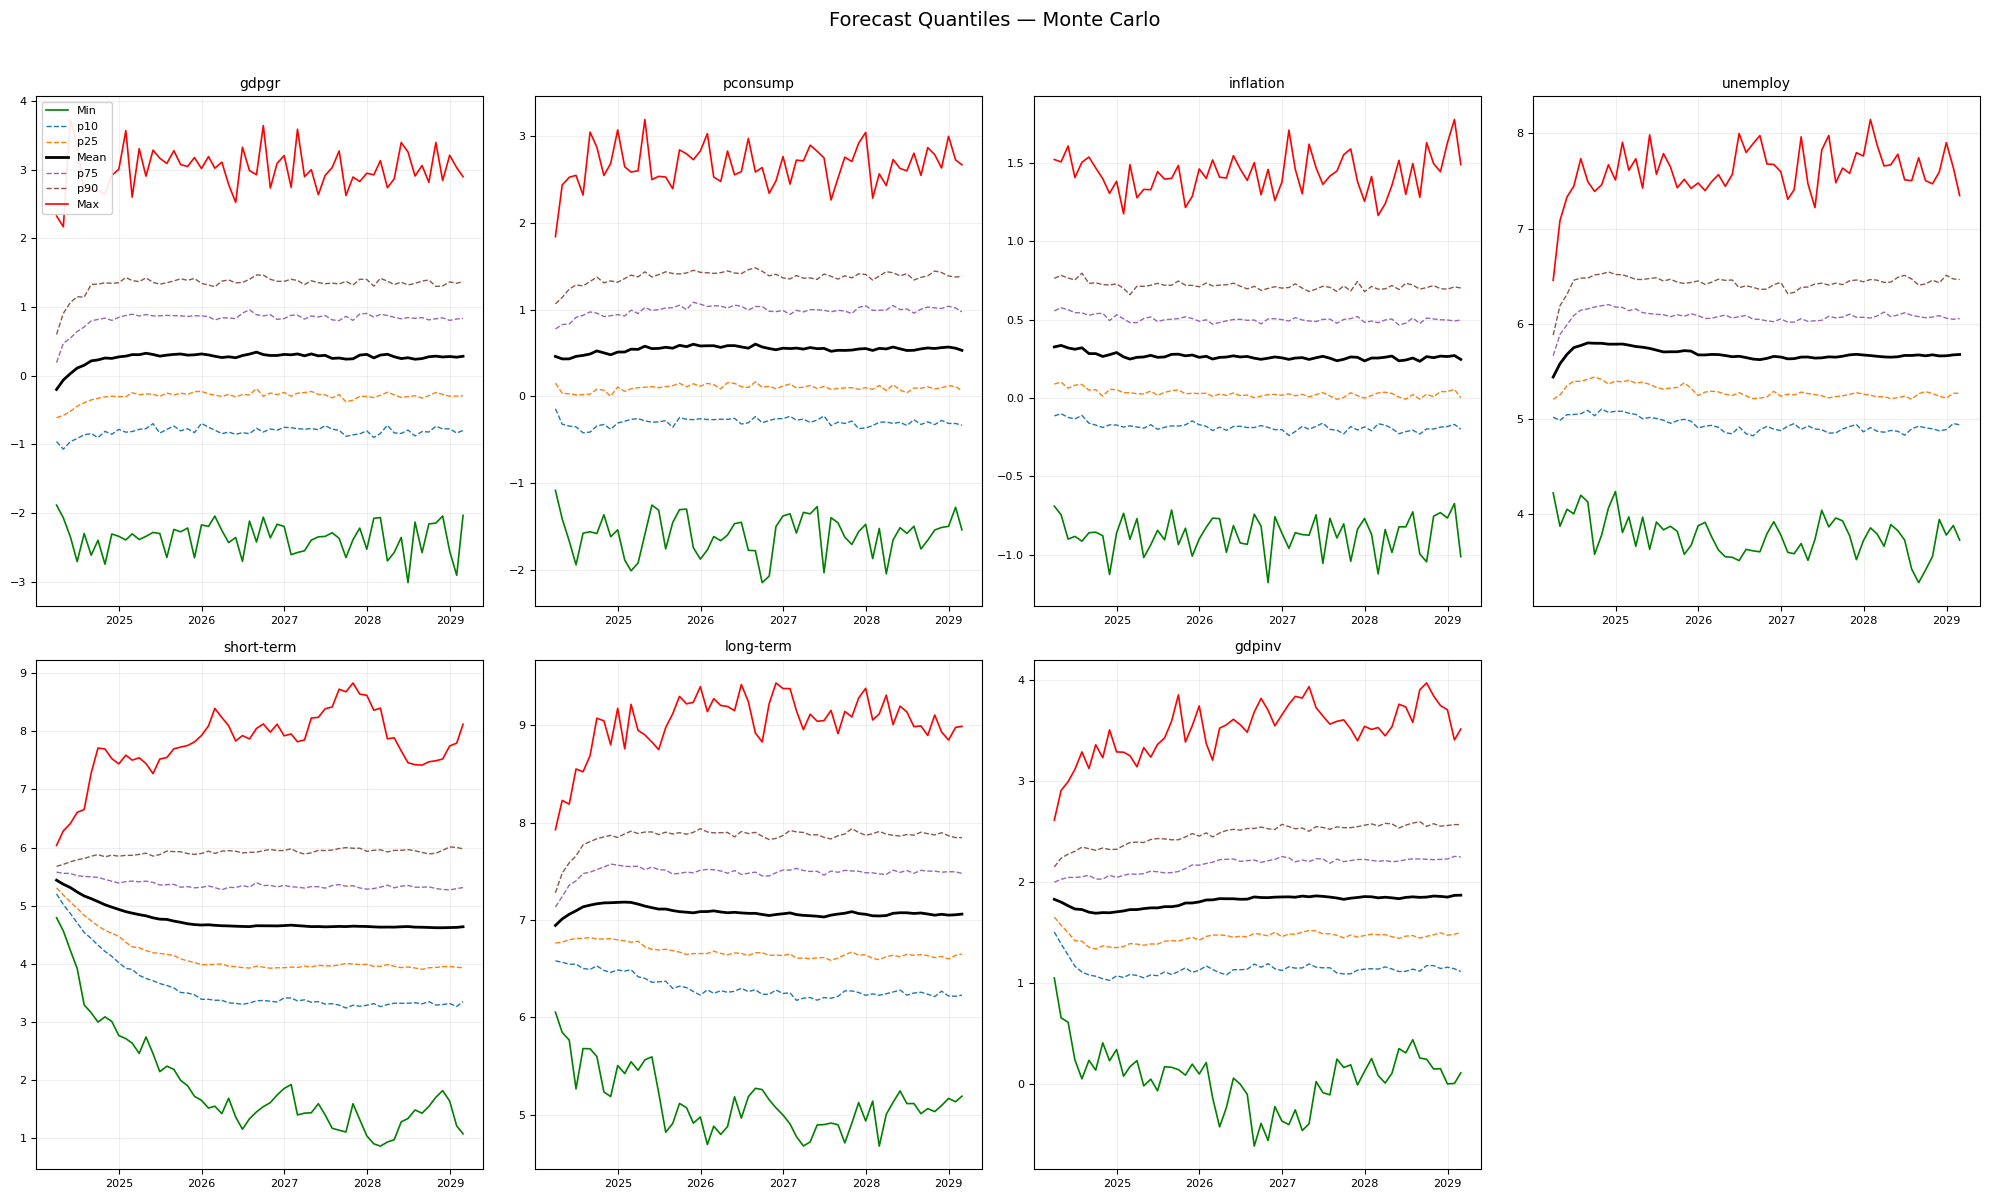

Saved: /content/plots/all_variables_bands.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/content/data"
OUTDIR = "/content/plots"
os.makedirs(OUTDIR, exist_ok=True)

# ---------- helpers ----------
def read_q(path):
    """Read CSV, try to use a date index if available."""
    df = pd.read_csv(path)
    # Try common date headers
    for cand in ["Date", "date", "DATE"]:
        if cand in df.columns:
            df[cand] = pd.to_datetime(df[cand], errors="coerce")
            if df[cand].notna().any():
                return df.set_index(cand)
    # Try first column as date if it looks like one
    first_col = df.columns[0]
    try:
        maybe_date = pd.to_datetime(df[first_col], errors="coerce")
        if maybe_date.notna().sum() >= len(df) * 0.8:
            return df.set_index(maybe_date).drop(columns=[first_col])
    except Exception:
        pass
    # Fallback: step index (1..N)
    df.index = range(1, len(df) + 1)
    return df

def numeric_only(df):
    return df.select_dtypes(include="number")

# ---------- load all quantile frames ----------
mean = numeric_only(read_q(f"{BASE}/X_future_mean.csv"))
pmin = numeric_only(read_q(f"{BASE}/X_future_pmin.csv"))
pmax = numeric_only(read_q(f"{BASE}/X_future_pmax.csv"))
p10  = numeric_only(read_q(f"{BASE}/X_future_p10.csv"))
p90  = numeric_only(read_q(f"{BASE}/X_future_p90.csv"))
p25  = numeric_only(read_q(f"{BASE}/X_future_p25.csv"))
p75  = numeric_only(read_q(f"{BASE}/X_future_p75.csv"))

# sinkronkan kolom: ambil irisan kolom yg ada di semuanya
cols = set(mean.columns) & set(pmin.columns) & set(pmax.columns) & \
       set(p10.columns)  & set(p90.columns)  & set(p25.columns)  & set(p75.columns)
cols = [c for c in mean.columns if c in cols]  # pertahankan urutan seperti di mean

if not cols:
    raise ValueError("Tidak ada kolom yang cocok di semua file quantile. Cek kembali nama kolom CSV.")

print(f"Variables to plot: {cols}")

# ---------- grid plot: all variables in one figure (lines only, custom colors) ----------
import math

vars_to_plot = cols
n = len(vars_to_plot)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 12), squeeze=False)
axes = axes.ravel()

LINE_STYLES = {
    "pmin": {"color": "green", "lw": 1.2, "ls": "-",  "label": "Min"},
    "p10":  {"color": "tab:blue", "lw": 1.0, "ls": "--", "label": "p10"},
    "p25":  {"color": "tab:orange", "lw": 1.0, "ls": "--", "label": "p25"},
    "mean": {"color": "black", "lw": 2.0, "ls": "-",  "label": "Mean"},
    "p75":  {"color": "tab:purple", "lw": 1.0, "ls": "--", "label": "p75"},
    "p90":  {"color": "tab:brown", "lw": 1.0, "ls": "--", "label": "p90"},
    "pmax": {"color": "red", "lw": 1.2, "ls": "-",  "label": "Max"},
}

for i, col in enumerate(vars_to_plot):
    ax = axes[i]

    s_mean = mean[col]
    s_pmin = pmin[col]; s_pmax = pmax[col]
    s_p10  = p10[col];  s_p90  = p90[col]
    s_p25  = p25[col];  s_p75  = p75[col]

    # Plot
    ax.plot(s_pmin.index, s_pmin.values, **LINE_STYLES["pmin"])
    ax.plot(s_p10.index,  s_p10.values,  **LINE_STYLES["p10"])
    ax.plot(s_p25.index,  s_p25.values,  **LINE_STYLES["p25"])
    ax.plot(s_mean.index, s_mean.values, **LINE_STYLES["mean"])
    ax.plot(s_p75.index,  s_p75.values,  **LINE_STYLES["p75"])
    ax.plot(s_p90.index,  s_p90.values,  **LINE_STYLES["p90"])
    ax.plot(s_pmax.index, s_pmax.values, **LINE_STYLES["pmax"])

    ax.set_title(col, fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=8)

    ymin = min(s_pmin.min(), s_p10.min(), s_p25.min(), s_mean.min())
    ymax = max(s_pmax.max(), s_p90.max(), s_p75.max(), s_mean.max())
    pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)

# legend di subplot pertama
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc="upper left", fontsize=8, framealpha=0.9)

# kosongkan axes jika ada sisa
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Forecast Quantiles — Monte Carlo", fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])

big_out = os.path.join(OUTDIR, "all_variables_bands.png")
plt.savefig(big_out, dpi=200)
plt.show()
print(f"Saved: {big_out}")



#SARIMAX Full model

########################################################################################################################
COMPLETE ESG MULTI-SCENARIO ANALYSIS (Extended Percentiles) — Leakage-Safe
Economic Scenario Generator with Stress Testing
########################################################################################################################


PROCESSING: GIDN1YR

MULTI-SCENARIO ANALYSIS FOR: GIDN1YR

SARIMAX Results for GIDN1YR
Dep. Variable:                     GIDN1YR   No. Observations:              89
Model:                SARIMAX(1, 1, 1)   Log Likelihood:           -13.465
Date:                     Fri, 14 Nov 2025   AIC:                       34.931
Time:                             03:29:21   BIC:                       36.870
Sample:                         31-10-2015   HQIC:                      34.213
                    -           28-02-2023
Covariance Type:                 opg

Key Model Parameters:
AR(1) coefficient:         -0.2572
MA(1) coefficient

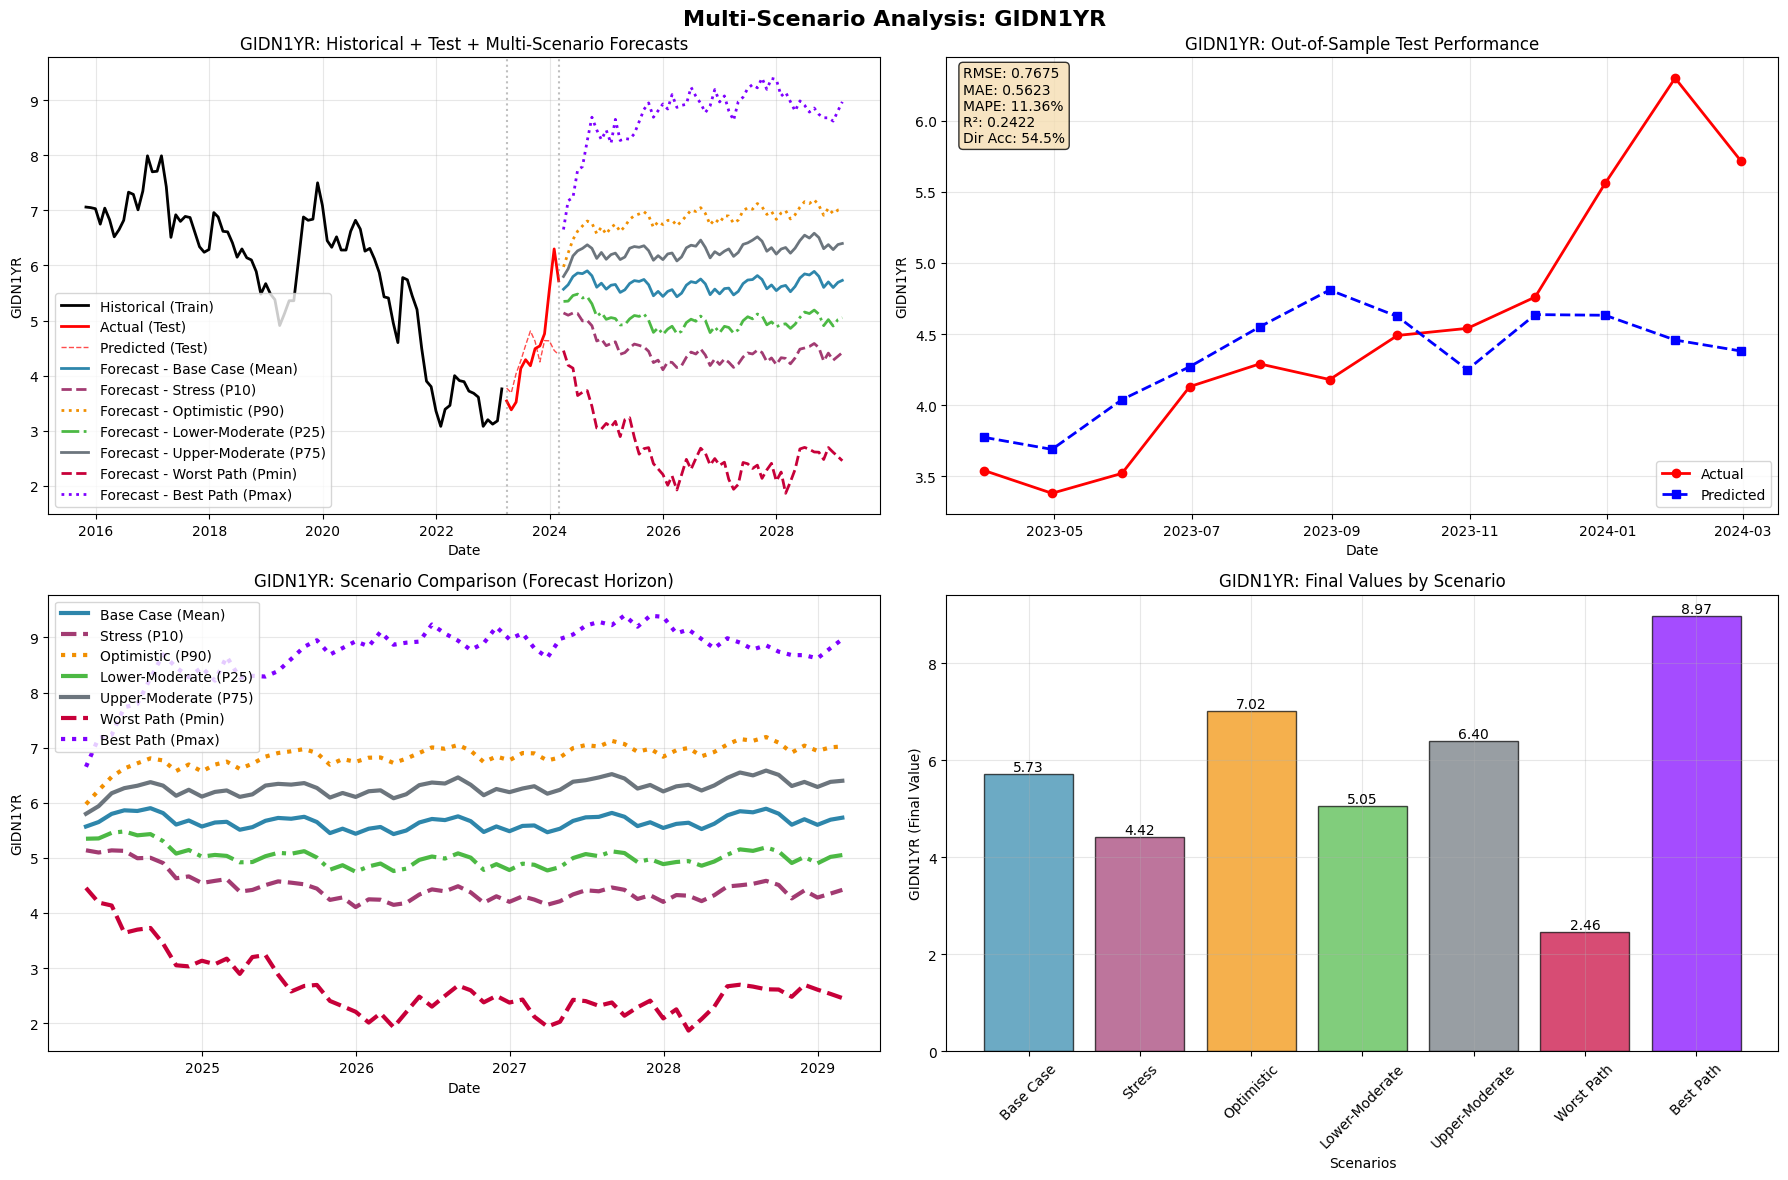


SCENARIO STATISTICS FOR GIDN1YR
                        Mean     Std     Min     P25  Median     P75     Max  \
Scenario                                                                       
Base Case (Mean)      5.6516  0.1210  5.4322  5.5670  5.6485  5.7379  5.9023   
Stress (P10)          4.4533  0.2596  4.1073  4.2762  4.4013  4.5329  5.1378   
Optimistic (P90)      6.8503  0.2115  5.9740  6.7458  6.9001  6.9935  7.1936   
Lower-Moderate (P25)  5.0194  0.1774  4.7479  4.8967  5.0114  5.0889  5.4805   
Upper-Moderate (P75)  6.2811  0.1432  5.8001  6.1963  6.2993  6.3695  6.5847   
Worst Path (Pmin)     2.6567  0.5698  1.8651  2.3003  2.4958  2.8833  4.4548   
Best Path (Pmax)      8.7179  0.5307  6.6529  8.6175  8.8354  9.0034  9.4008   

                       Final  
Scenario                      
Base Case (Mean)      5.7294  
Stress (P10)          4.4196  
Optimistic (P90)      7.0223  
Lower-Moderate (P25)  5.0514  
Upper-Moderate (P75)  6.3994  
Worst Path (Pmin)     2.4560 

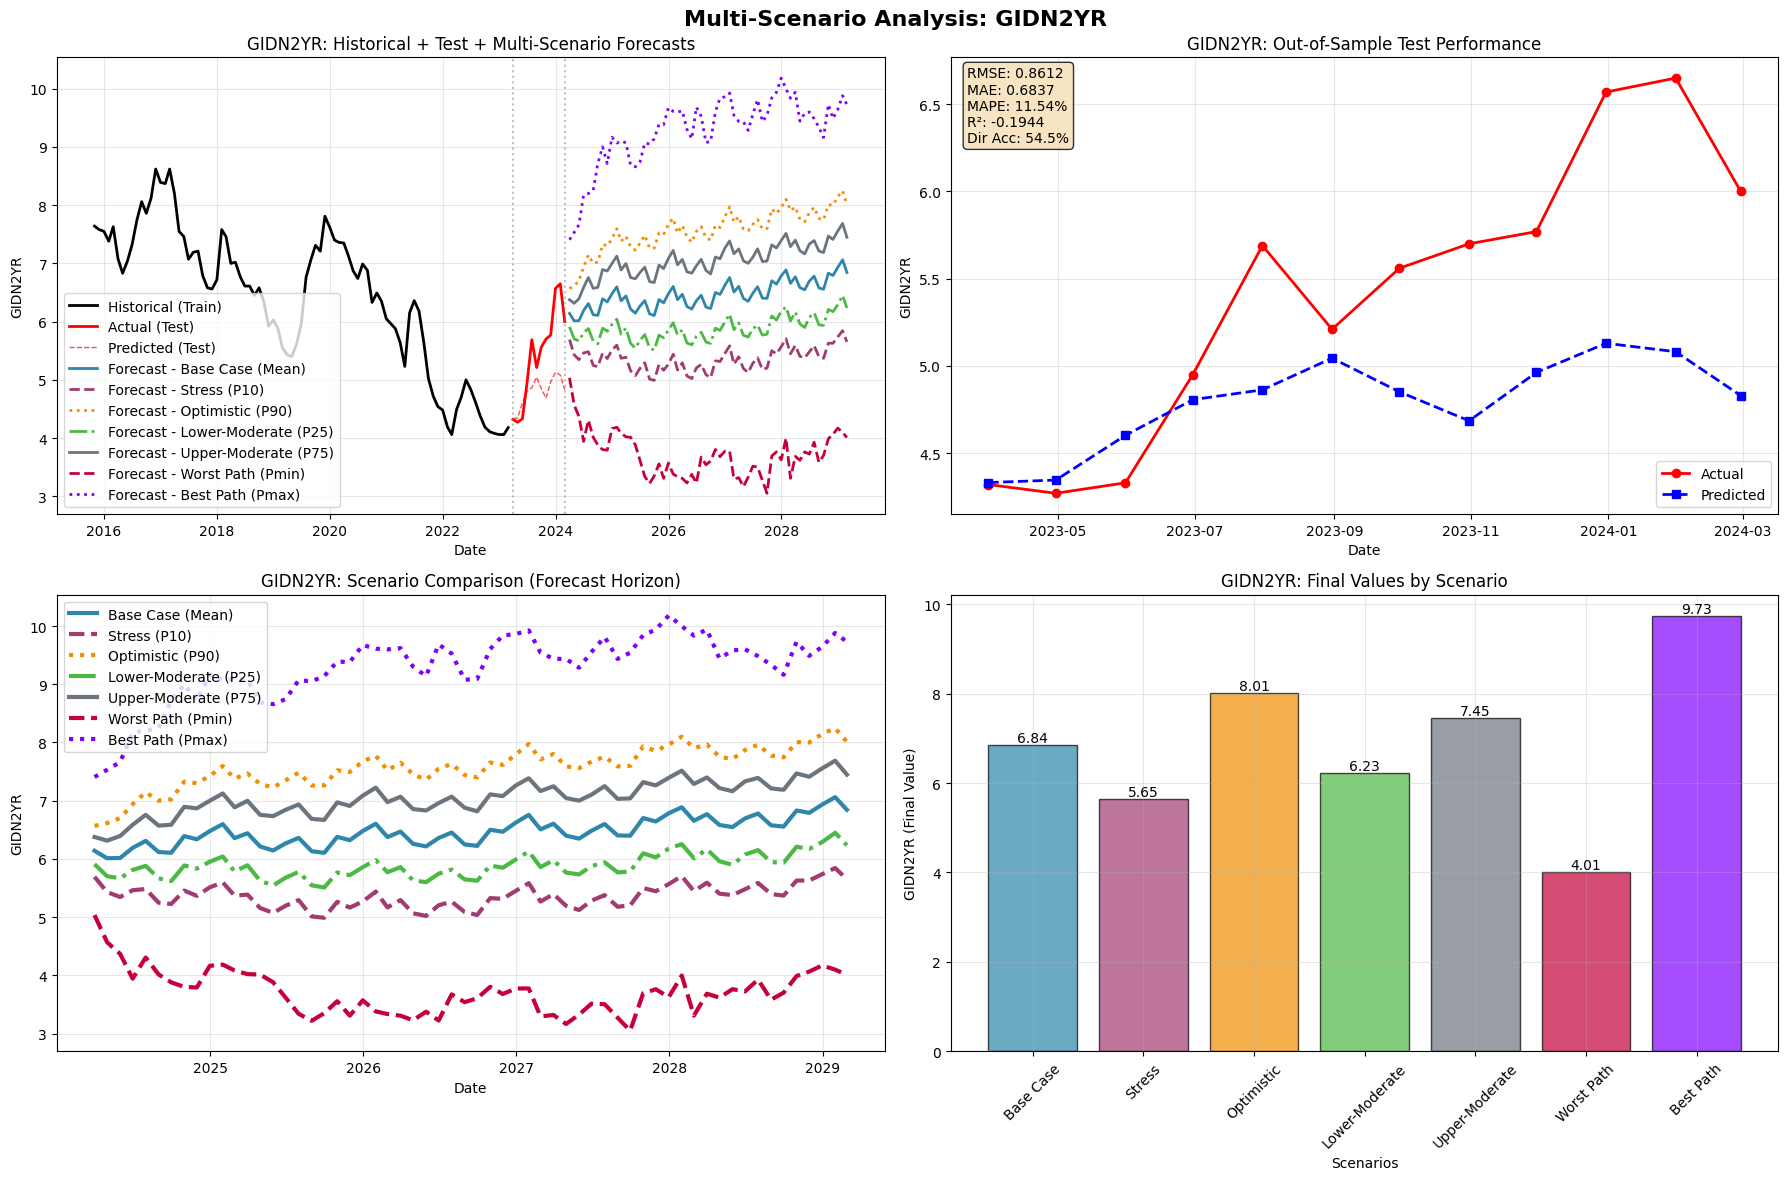


SCENARIO STATISTICS FOR GIDN2YR
                        Mean     Std     Min     P25  Median     P75      Max  \
Scenario                                                                        
Base Case (Mean)      6.4639  0.2426  6.0120  6.2991  6.4596  6.6097   7.0611   
Stress (P10)          5.3606  0.1989  4.9889  5.2037  5.3701  5.4804   5.8432   
Optimistic (P90)      7.5681  0.3609  6.5673  7.3758  7.5965  7.7970   8.2453   
Lower-Moderate (P25)  5.8827  0.2072  5.5091  5.7431  5.8685  5.9956   6.4486   
Upper-Moderate (P75)  7.0433  0.3002  6.3139  6.8648  7.0562  7.2529   7.6863   
Worst Path (Pmin)     3.7150  0.3794  3.0514  3.3692  3.6890  3.9910   5.0352   
Best Path (Pmax)      9.2763  0.5998  7.4059  9.0694  9.4366  9.6505  10.1820   

                       Final  
Scenario                      
Base Case (Mean)      6.8433  
Stress (P10)          5.6515  
Optimistic (P90)      8.0102  
Lower-Moderate (P25)  6.2339  
Upper-Moderate (P75)  7.4482  
Worst Path (Pmin)   

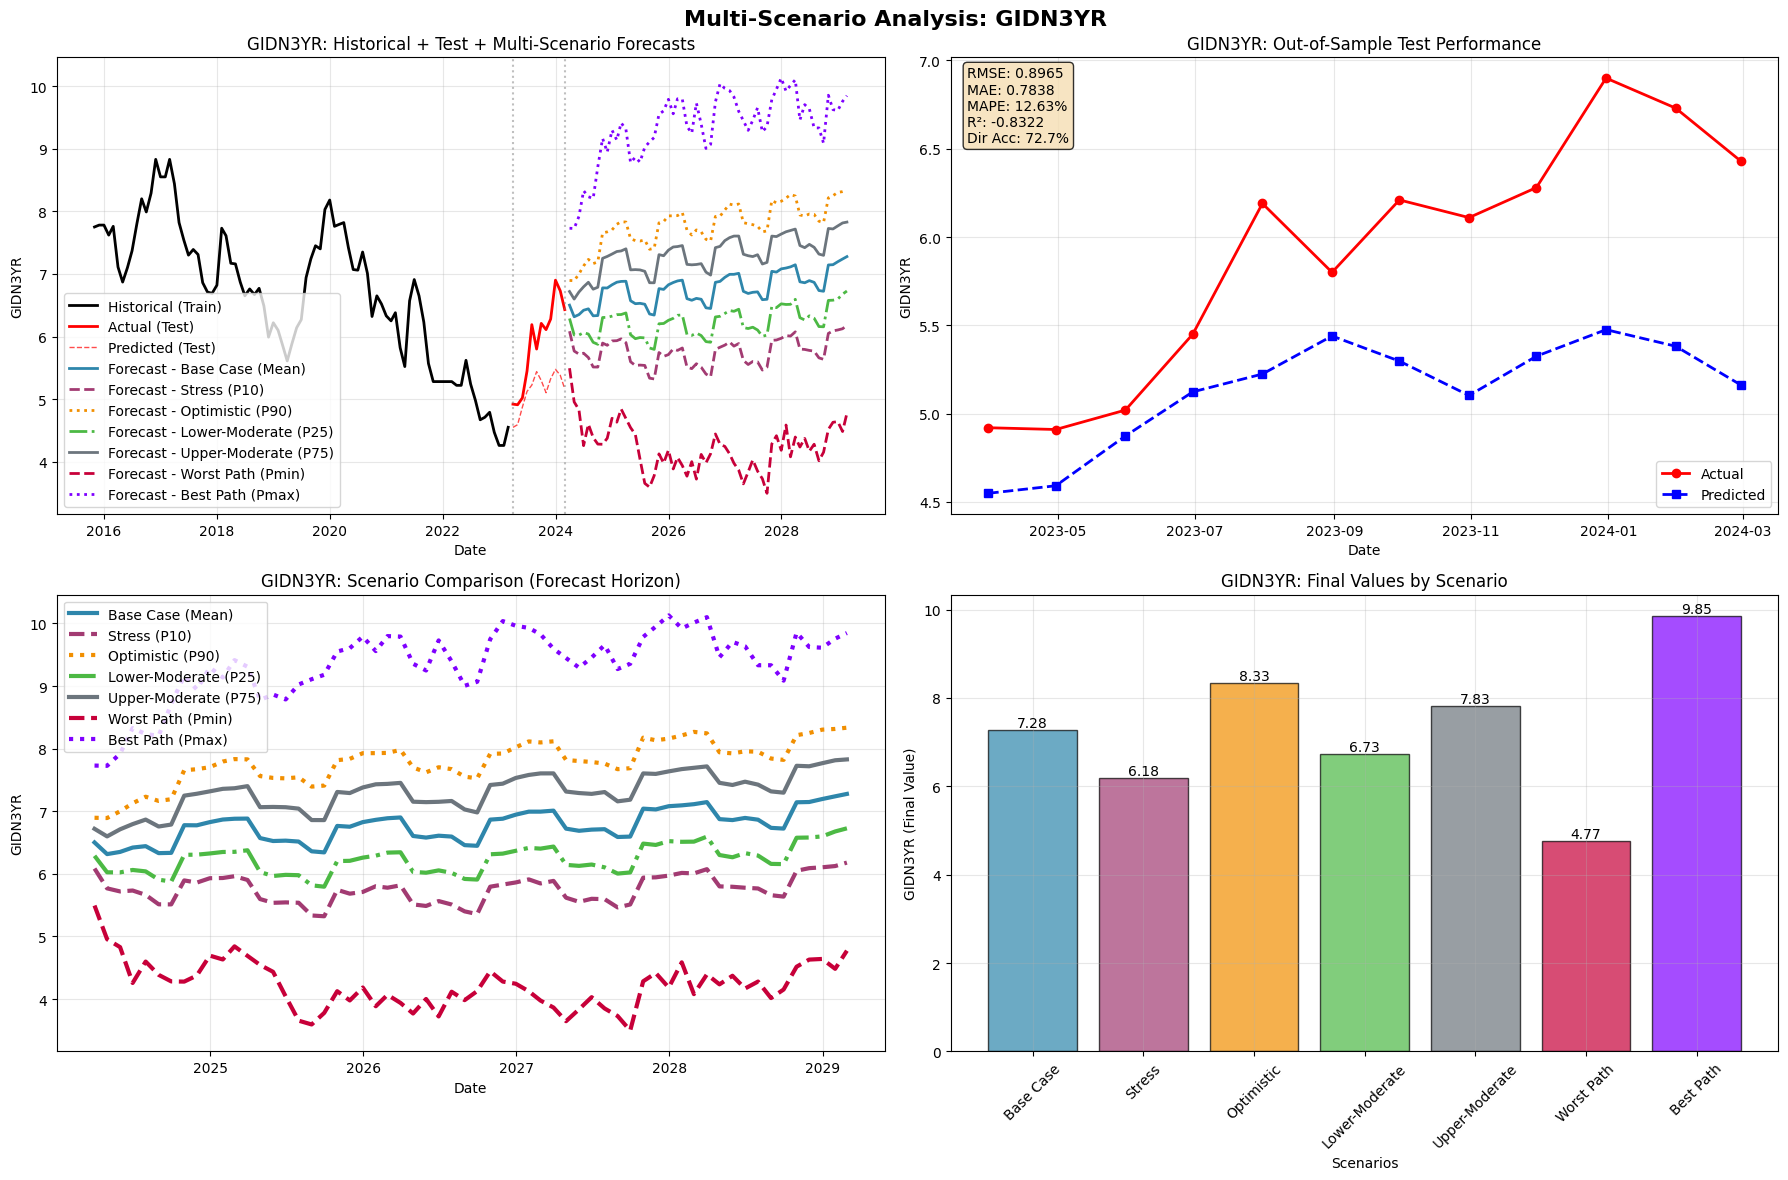


SCENARIO STATISTICS FOR GIDN3YR
                        Mean     Std     Min     P25  Median     P75      Max  \
Scenario                                                                        
Base Case (Mean)      6.7665  0.2576  6.3153  6.5772  6.7761  6.9119   7.2766   
Stress (P10)          5.7521  0.2172  5.3222  5.5622  5.7730  5.9162   6.1795   
Optimistic (P90)      7.7818  0.3533  6.8914  7.6063  7.8196  7.9908   8.3345   
Lower-Moderate (P25)  6.2325  0.2280  5.7947  6.0278  6.2762  6.3703   6.7269   
Upper-Moderate (P75)  7.2992  0.3052  6.5981  7.1262  7.3157  7.4871   7.8278   
Worst Path (Pmin)     4.2331  0.3785  3.4959  3.9811  4.2095  4.4530   5.4938   
Best Path (Pmax)      9.3410  0.5684  7.7256  9.1034  9.4305  9.7637  10.1281   

                       Final  
Scenario                      
Base Case (Mean)      7.2766  
Stress (P10)          6.1795  
Optimistic (P90)      8.3345  
Lower-Moderate (P25)  6.7269  
Upper-Moderate (P75)  7.8278  
Worst Path (Pmin)   

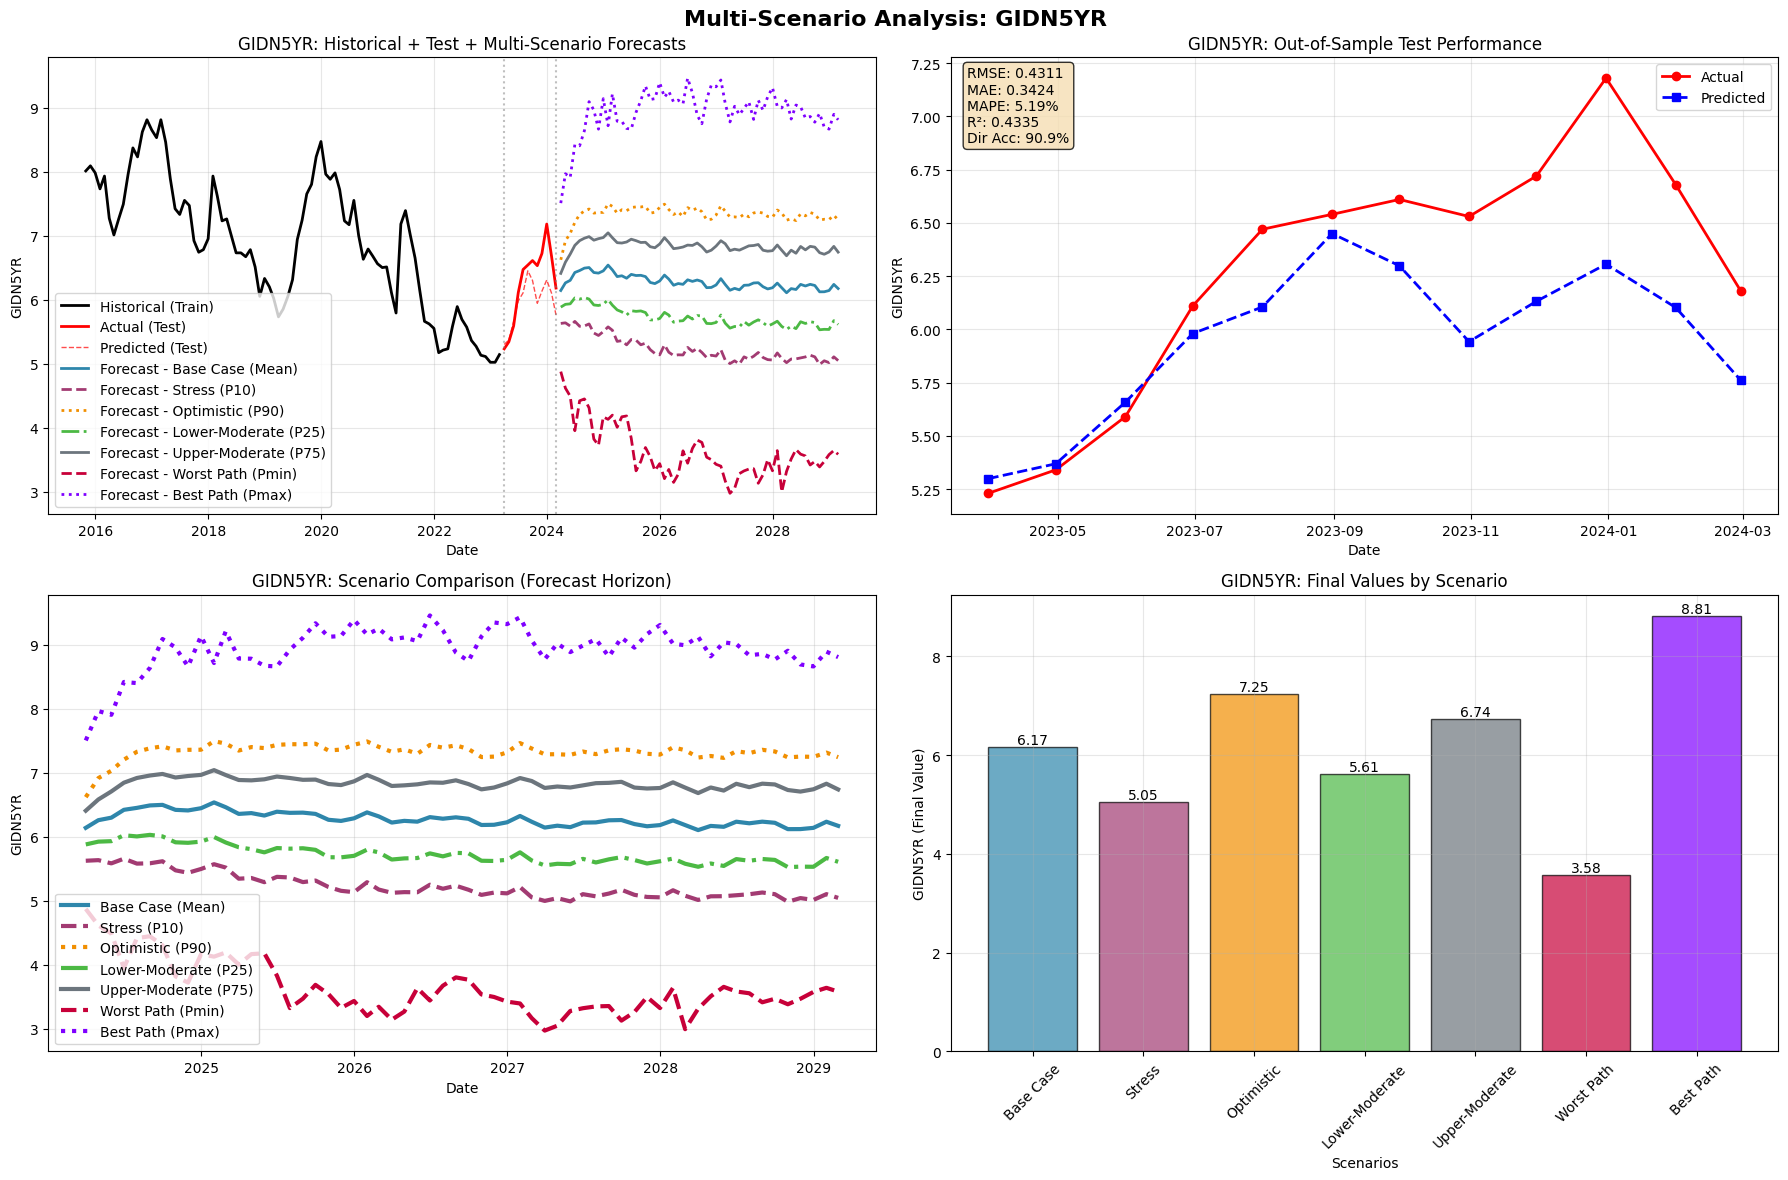


SCENARIO STATISTICS FOR GIDN5YR
                        Mean     Std     Min     P25  Median     P75     Max  \
Scenario                                                                       
Base Case (Mean)      6.2763  0.1067  6.1064  6.1885  6.2542  6.3593  6.5387   
Stress (P10)          5.2290  0.1967  4.9861  5.0863  5.1472  5.3495  5.6593   
Optimistic (P90)      7.3254  0.1348  6.6211  7.2891  7.3501  7.3955  7.4970   
Lower-Moderate (P25)  5.7243  0.1424  5.5280  5.6257  5.6754  5.8175  6.0319   
Upper-Moderate (P75)  6.8286  0.1014  6.4093  6.7713  6.8314  6.8920  7.0432   
Worst Path (Pmin)     3.6296  0.4202  2.9730  3.3407  3.5231  3.8082  4.8741   
Best Path (Pmax)      8.9246  0.3546  7.5073  8.7825  8.9922  9.1279  9.4611   

                       Final  
Scenario                      
Base Case (Mean)      6.1725  
Stress (P10)          5.0466  
Optimistic (P90)      7.2456  
Lower-Moderate (P25)  5.6108  
Upper-Moderate (P75)  6.7414  
Worst Path (Pmin)     3.5817 

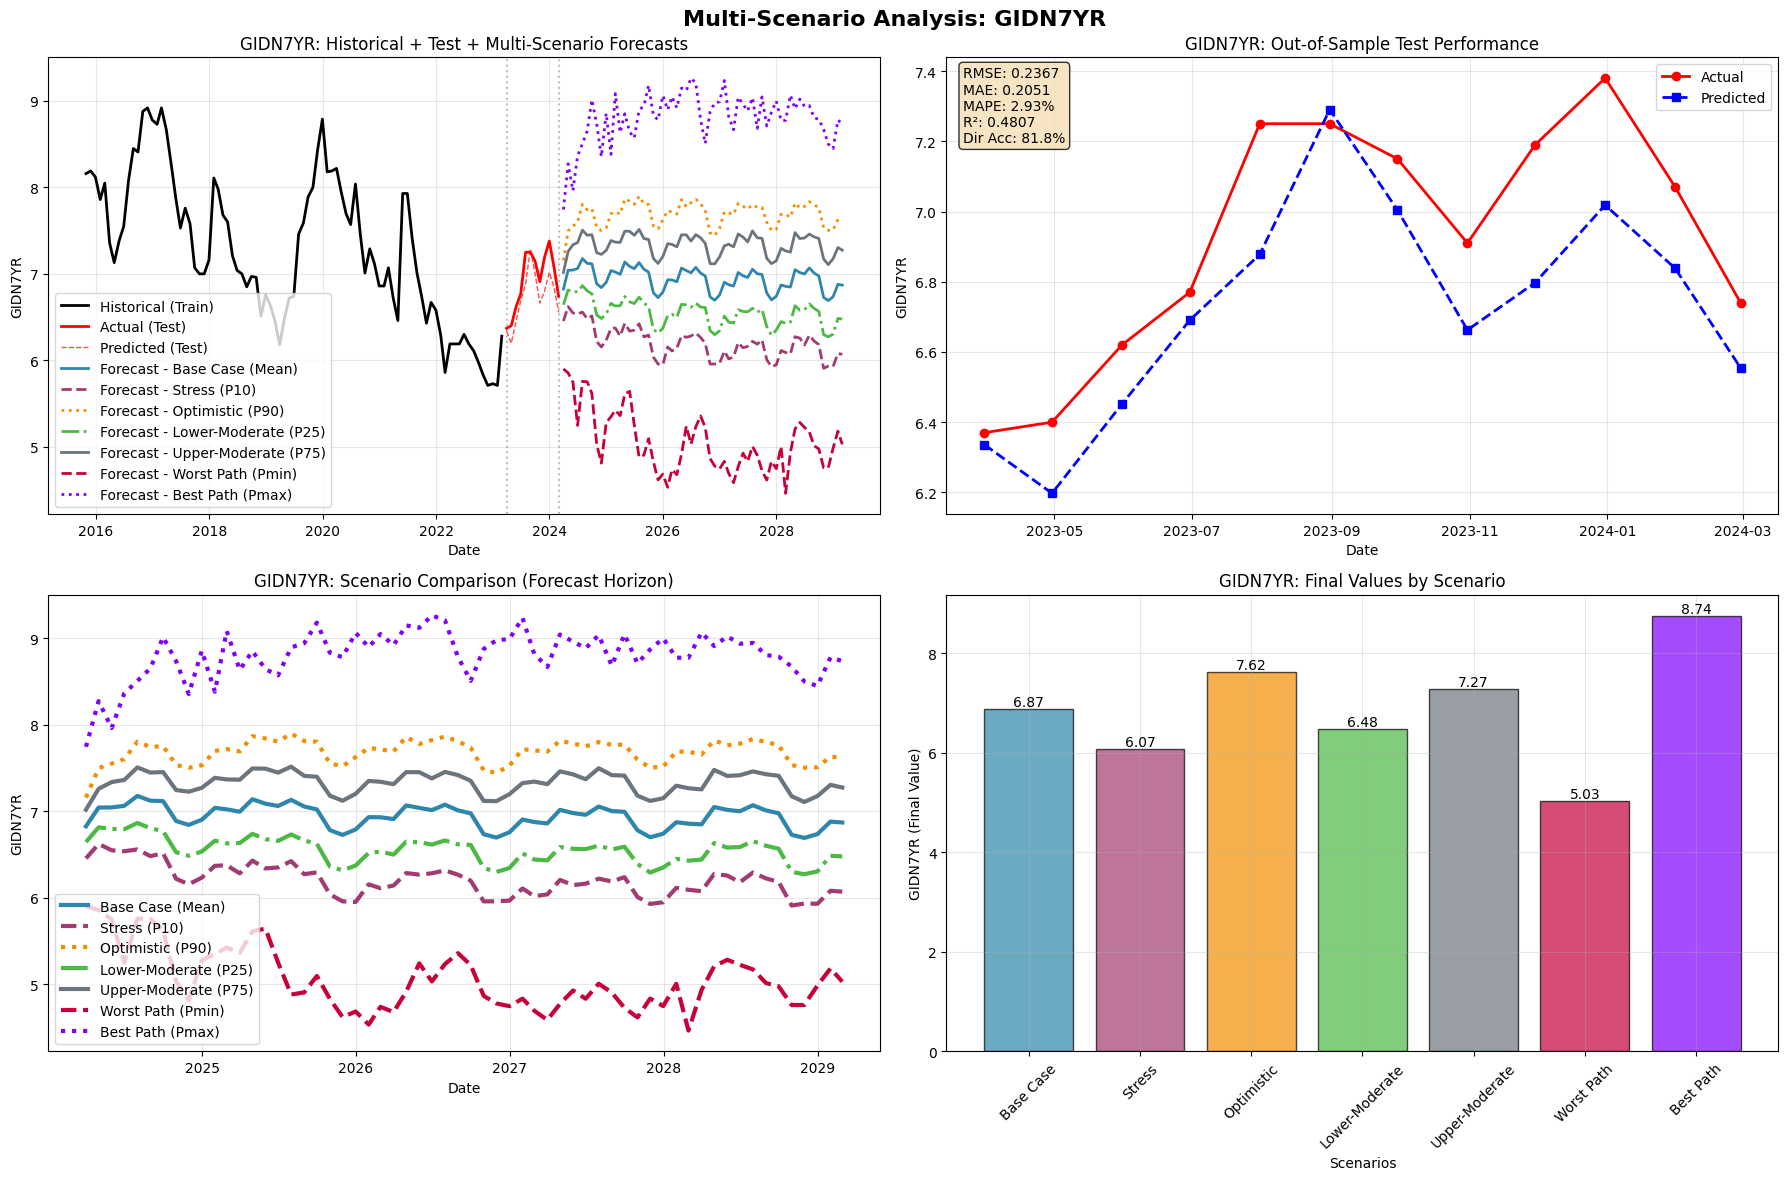


SCENARIO STATISTICS FOR GIDN7YR
                        Mean     Std     Min     P25  Median     P75     Max  \
Scenario                                                                       
Base Case (Mean)      6.9408  0.1307  6.6910  6.8539  6.9776  7.0428  7.1768   
Stress (P10)          6.2014  0.1815  5.9085  6.0736  6.2007  6.2913  6.6213   
Optimistic (P90)      7.6827  0.1412  7.1568  7.5521  7.7163  7.8000  7.8981   
Lower-Moderate (P25)  6.5508  0.1489  6.2714  6.4413  6.5726  6.6447  6.8638   
Upper-Moderate (P75)  7.3316  0.1237  7.0177  7.2503  7.3570  7.4268  7.5149   
Worst Path (Pmin)     5.0566  0.3534  4.4622  4.7751  4.9932  5.2481  5.9006   
Best Path (Pmax)      8.8034  0.2911  7.7446  8.6713  8.8549  9.0032  9.2648   

                       Final  
Scenario                      
Base Case (Mean)      6.8693  
Stress (P10)          6.0692  
Optimistic (P90)      7.6181  
Lower-Moderate (P25)  6.4770  
Upper-Moderate (P75)  7.2741  
Worst Path (Pmin)     5.0286 

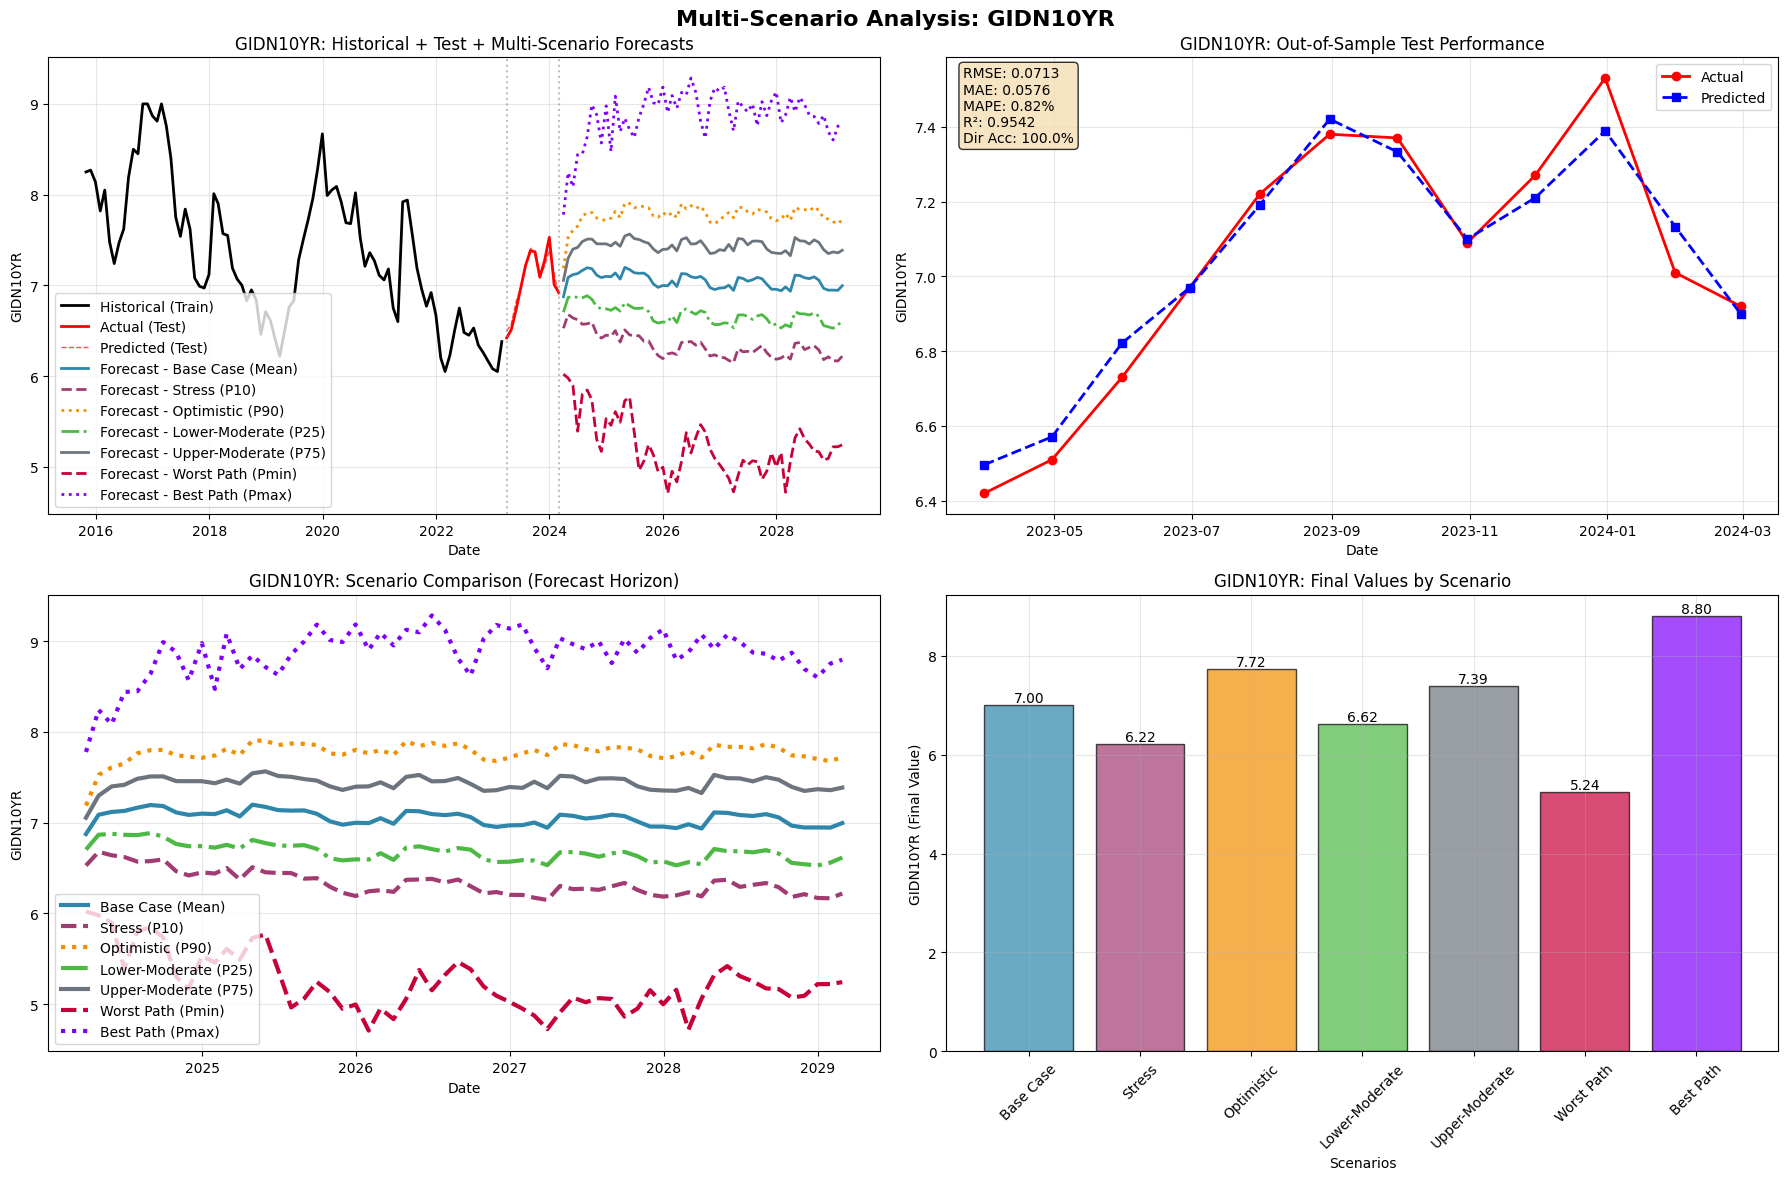


SCENARIO STATISTICS FOR GIDN10YR
                        Mean     Std     Min     P25  Median     P75     Max  \
Scenario                                                                       
Base Case (Mean)      7.0534  0.0774  6.8746  6.9814  7.0733  7.1089  7.1983   
Stress (P10)          6.3361  0.1349  6.1481  6.2255  6.3010  6.4237  6.6783   
Optimistic (P90)      7.7725  0.1072  7.1882  7.7305  7.7955  7.8373  7.9067   
Lower-Moderate (P25)  6.6753  0.0972  6.5276  6.5890  6.6765  6.7394  6.8856   
Upper-Moderate (P75)  7.4320  0.0794  7.0544  7.3833  7.4485  7.4881  7.5653   
Worst Path (Pmin)     5.2346  0.3151  4.7081  5.0241  5.1678  5.3865  6.0207   
Best Path (Pmax)      8.8599  0.2766  7.7791  8.7445  8.9083  9.0325  9.2844   

                       Final  
Scenario                      
Base Case (Mean)      6.9958  
Stress (P10)          6.2195  
Optimistic (P90)      7.7234  
Lower-Moderate (P25)  6.6153  
Upper-Moderate (P75)  7.3865  
Worst Path (Pmin)     5.2424

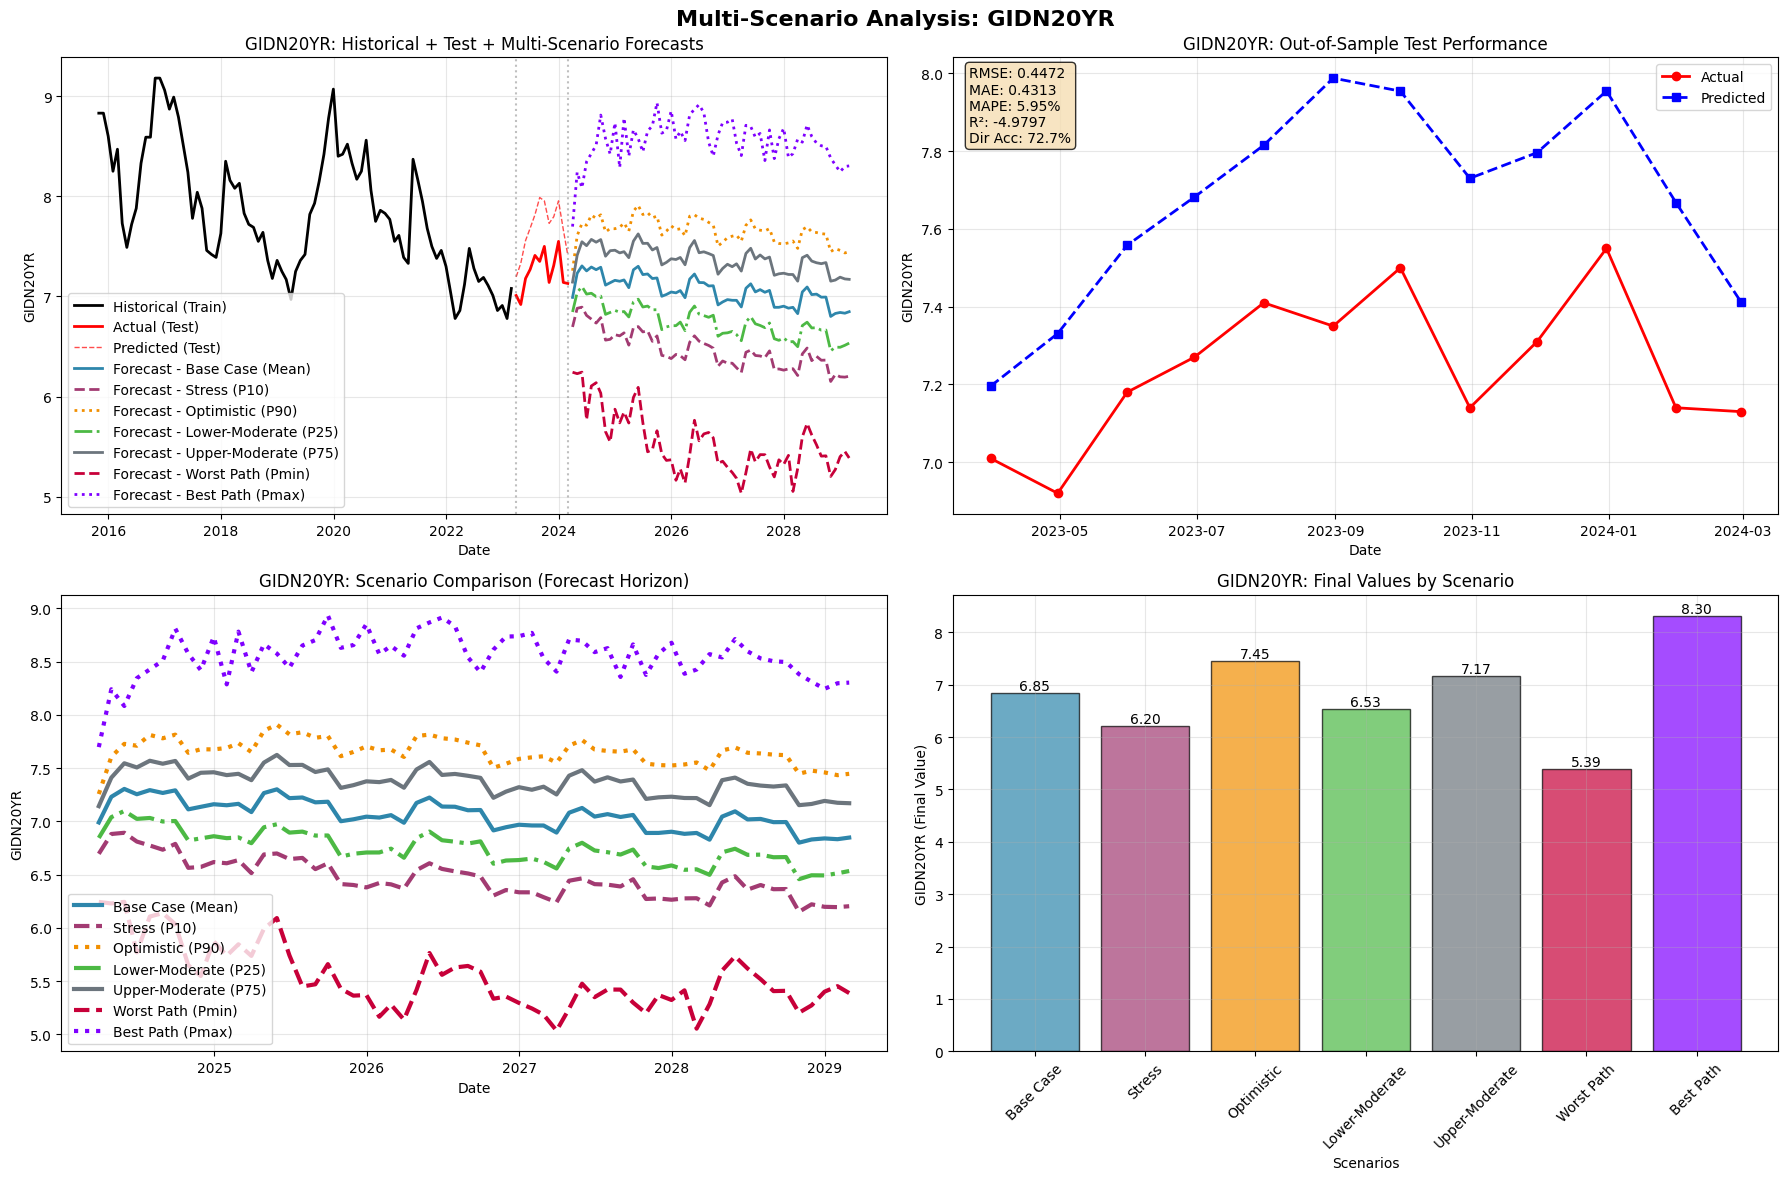


SCENARIO STATISTICS FOR GIDN20YR
                        Mean     Std     Min     P25  Median     P75     Max  \
Scenario                                                                       
Base Case (Mean)      7.0592  0.1390  6.8007  6.9619  7.0523  7.1624  7.3053   
Stress (P10)          6.4658  0.1838  6.1515  6.3344  6.4241  6.6067  6.8934   
Optimistic (P90)      7.6534  0.1249  7.2571  7.5787  7.6640  7.7359  7.9092   
Lower-Moderate (P25)  6.7460  0.1579  6.4578  6.6361  6.7315  6.8464  7.0984   
Upper-Moderate (P75)  7.3731  0.1246  7.1436  7.2930  7.3874  7.4581  7.6246   
Worst Path (Pmin)     5.5370  0.3052  5.0355  5.3319  5.4391  5.7336  6.2446   
Best Path (Pmax)      8.5493  0.2166  7.6978  8.4053  8.5731  8.6983  8.9348   

                       Final  
Scenario                      
Base Case (Mean)      6.8482  
Stress (P10)          6.2037  
Optimistic (P90)      7.4471  
Lower-Moderate (P25)  6.5343  
Upper-Moderate (P75)  7.1711  
Worst Path (Pmin)     5.3880

In [ ]:
# ===== COMPLETE ESG MULTI-SCENARIO ANALYSIS — EXTENDED PERCENTILES (LEAKAGE-SAFE) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


TEST_HORIZON = 12
ORDER = (1, 1, 1)
SEASONAL = (0, 1, 1, 12)
ENF_STAT = False
ENF_INV = False

# PRODUKSI: refit ke full history sebelum forecast skenario (tanpa menyentuh test saat evaluasi)
REFIT_ON_FULL_HISTORY_BEFORE_FORECAST = True

# ---------------- LOAD CORE DATA ----------------
raw = pd.read_csv(CSV_PATH)
if "Unnamed: 0" in raw.columns and "Date" not in raw.columns:
    raw = raw.rename(columns={"Unnamed: 0": "Date"})
raw["Date"] = pd.to_datetime(raw["Date"])
df = raw.set_index("Date").sort_index()
df.index = df.index.to_period("M").to_timestamp("M")
df = df.apply(pd.to_numeric, errors="coerce")

# -------- Load VAR scenario results (mean, p10, p25, p75, p90, pmin, pmax) --------
def _safe_read(path: Path):
    """
    Read scenario CSV robustly and normalize index to MonthEnd.
    Accepts 'Date' column or first column as date.
    """
    try:
        d = pd.read_csv(path)
        if d.empty:
            return None
        # detect date column
        date_col = None
        for c in d.columns:
            cl = str(c).lower()
            if cl in ("date","tanggal","period","periode") or "unnamed" in cl:
                date_col = c; break
        if date_col is None:
            date_col = d.columns[0]
        d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
        d = d.dropna(subset=[date_col]).set_index(date_col).sort_index()
        d.index = d.index.to_period("M").to_timestamp("M")
        # keep only exog cols if present
        return d
    except Exception:
        return None

X_future_mean = _safe_read(OUT_DIR / "X_future_mean.csv")
X_future_p10  = _safe_read(OUT_DIR / "X_future_p10.csv")
X_future_p25  = _safe_read(OUT_DIR / "X_future_p25.csv")
X_future_p75  = _safe_read(OUT_DIR / "X_future_p75.csv")
X_future_p90  = _safe_read(OUT_DIR / "X_future_p90.csv")
X_future_pmin = _safe_read(OUT_DIR / "X_future_pmin.csv")  # min per step
X_future_pmax = _safe_read(OUT_DIR / "X_future_pmax.csv")  # max per step

if X_future_mean is None:
    raise FileNotFoundError("Minimal file 'X_future_mean.csv' harus tersedia di OUT_DIR.")

# Validasi kolom EXOG untuk semua file yang ada
for name, dfe in {
    "mean": X_future_mean, "p10": X_future_p10, "p25": X_future_p25,
    "p75": X_future_p75, "p90": X_future_p90, "pmin": X_future_pmin, "pmax": X_future_pmax
}.items():
    if dfe is None:
        continue
    missing = [c for c in EXOG_COLS if c not in dfe.columns]
    if missing:
        raise ValueError(f"File {name} tidak punya kolom exog lengkap. Missing: {missing}")

# -------- Build SCENARIOS dict dinamis (hanya yang tersedia) --------
_SCN_STYLE = [
    ("#2E86AB", "-"),   # Base
    ("#A23B72", "--"),  # P10
    ("#F18F01", ":"),   # P90
    ("#4CB944", "-."),  # P25
    ("#6C757D", "-"),   # P75
    ("#C70039", "--"),  # Pmin
    ("#7F00FF", ":"),   # Pmax
]
_SCN_RAW = [
    ("Base",        X_future_mean, "Base Case (Mean)"),
    ("Stress",      X_future_p10,  "Stress (P10)"),
    ("Optimistic",  X_future_p90,  "Optimistic (P90)"),
    ("P25",         X_future_p25,  "Lower-Moderate (P25)"),
    ("P75",         X_future_p75,  "Upper-Moderate (P75)"),
    ("Worst",       X_future_pmin, "Worst Path (Pmin)"),
    ("Best",        X_future_pmax, "Best Path (Pmax)"),
]

SCENARIOS = {}
k = 0
for key, df_ex, desc in _SCN_RAW:
    if df_ex is None:
        continue
    color, ls = _SCN_STYLE[k % len(_SCN_STYLE)]
    # ensure only EXOG_COLS and normalized index
    df_ex = df_ex.copy()
    df_ex.index = df_ex.index.to_period("M").to_timestamp("M")
    df_ex = df_ex.reindex(columns=EXOG_COLS)
    SCENARIOS[key] = {
        "data": df_ex,
        "description": desc,
        "color": color,
        "linestyle": ls
    }
    k += 1

if "Base" not in SCENARIOS:
    raise RuntimeError("Skenario 'Base' (mean) wajib ada di SCENARIOS.")

# ---------------- HELPERS ----------------
def safe_mape(actual, pred):
    a = pd.Series(actual).astype(float)
    p = pd.Series(pred).astype(float)
    denom = a.replace(0, np.nan).abs()
    return (np.abs((a - p) / denom)).mean(skipna=True) * 100

def dir_labels(s):
    d = pd.Series(s).diff().dropna()
    return np.sign(d).replace({1: "Up", -1: "Down", 0: "Flat"})

def calculate_residual_diagnostics(residuals):
    """Calculate diagnostic statistics from residuals (approx)."""
    residuals = residuals.dropna()
    # Ljung-Box approx (lag=1)
    try:
        autocorr = residuals.autocorr(lag=1)
        n = len(residuals)
        ljung_stat = n * (n + 2) * (autocorr**2) / (n - 1)
        ljung_pval = 1 - stats.chi2.cdf(ljung_stat, df=1)
    except:
        ljung_stat, ljung_pval = np.nan, np.nan
    # Jarque-Bera
    try:
        jb_stat, jb_pval = stats.jarque_bera(residuals)
    except:
        jb_stat, jb_pval = np.nan, np.nan
    # Heteroskedasticity (split-half variance ratio)
    try:
        n = len(residuals)
        mid = n // 2
        var1 = np.var(residuals.iloc[:mid])
        var2 = np.var(residuals.iloc[mid:])
        het_stat = max(var1, var2) / min(var1, var2) if min(var1, var2) > 0 else np.nan
        het_pval = 2 * (1 - stats.f.cdf(het_stat, mid-1, n-mid-1)) if not np.isnan(het_stat) else np.nan
    except:
        het_stat, het_pval = np.nan, np.nan
    # Skewness & Kurtosis
    try:
        skew = stats.skew(residuals)
        kurt = stats.kurtosis(residuals, fisher=False)
    except:
        skew, kurt = np.nan, np.nan
    return {
        'ljung_box_stat': ljung_stat, 'ljung_box_pval': ljung_pval,
        'jarque_bera_stat': jb_stat, 'jarque_bera_pval': jb_pval,
        'heterosked_stat': het_stat, 'heterosked_pval': het_pval,
        'skewness': skew, 'kurtosis': kurt
    }

def estimate_model_info_criteria(residuals, n_params=4):
    """Estimate log-likelihood, AIC, BIC, HQIC from residuals."""
    n = len(residuals.dropna())
    if n == 0:
        return {'llf': np.nan, 'aic': np.nan, 'bic': np.nan, 'hqic': np.nan}
    mse = np.var(residuals.dropna())
    if mse <= 0 or np.isnan(mse):
        return {'llf': np.nan, 'aic': np.nan, 'bic': np.nan, 'hqic': np.nan}
    llf = -0.5 * n * (np.log(2 * np.pi * mse) + 1)
    aic = 2 * n_params - 2 * llf
    bic = n_params * np.log(n) - 2 * llf
    hqic = 2 * n_params * np.log(np.log(n)) - 2 * llf
    return {'llf': llf, 'aic': aic, 'bic': bic, 'hqic': hqic}

def print_sarimax_results(res, target, train_y, test_y, y_pred_test,
                          test_metrics, diagnostics, model_info):
    """Print comprehensive SARIMAX results."""
    print(f"\n{'='*80}")
    print(f"SARIMAX Results for {target}")
    print(f"{'='*80}")
    print(f"Dep. Variable:        {target:>20}   No. Observations:      {len(res.model.endog):>10}")
    print(f"Model:                SARIMAX{ORDER}   Log Likelihood:        {model_info['llf']:>10.3f}")
    print(f"Date:                 {pd.Timestamp.now().strftime('%a, %d %b %Y'):>20}   AIC:                   {model_info['aic']:>10.3f}")
    print(f"Time:                 {pd.Timestamp.now().strftime('%H:%M:%S'):>20}   BIC:                   {model_info['bic']:>10.3f}")
    print(f"Sample:               {train_y.index[0].strftime('%d-%m-%Y'):>20}   HQIC:                  {model_info['hqic']:>10.3f}")
    print(f"                    - {train_y.index[-1].strftime('%d-%m-%Y'):>20}")
    print(f"Covariance Type:                 opg")

    print(f"\n{'='*80}")
    print(f"Key Model Parameters:")
    print(f"{'='*80}")
    try:
        params = res.params
        print(f"AR(1) coefficient:      {params.get('ar.L1', 'N/A'):>10.4f}")
        print(f"MA(1) coefficient:      {params.get('ma.L1', 'N/A'):>10.4f}")
        print(f"Sigma2:                 {params.get('sigma2', 'N/A'):>10.4f}")
    except:
        print("Parameter details unavailable")

    print(f"\n{'='*80}")
    print(f"Ljung-Box (L1) (Q):     {diagnostics['ljung_box_stat']:>10.2f}   Jarque-Bera (JB):      {diagnostics['jarque_bera_stat']:>10.2f}")
    print(f"Prob(Q):                {diagnostics['ljung_box_pval']:>10.3f}   Prob(JB):              {diagnostics['jarque_bera_pval']:>10.3f}")
    print(f"Heteroskedasticity (H): {diagnostics['heterosked_stat']:>10.2f}   Skew:                  {diagnostics['skewness']:>10.2f}")
    print(f"Prob(H) (two-sided):    {diagnostics['heterosked_pval']:>10.3f}   Kurtosis:              {diagnostics['kurtosis']:>10.2f}")

    print(f"\n{'='*80}")
    print("OUT-OF-SAMPLE TEST PERFORMANCE")
    print(f"{'='*80}")
    print(f"Test Horizon:           {len(test_y):>10} months")
    print(f"RMSE:                   {test_metrics['rmse']:>10.4f}")
    print(f"MAE:                    {test_metrics['mae']:>10.4f}")
    print(f"MAPE (%):               {test_metrics['mape']:>10.2f}")
    print(f"R²:                     {test_metrics['r2']:>10.4f}")
    print(f"Direction Accuracy (%): {test_metrics['dir_acc']:>10.2f}")

# ---------------- CORE: SAFE MULTI-SCENARIO ----------------
def run_multi_scenario_analysis(target, refit_on_full_history_before_forecast=REFIT_ON_FULL_HISTORY_BEFORE_FORECAST):
    """
    Evaluasi OOS murni (train-only) lalu forecast skenario
    yang DIJAMIN mulai setelah test_end (dan history_end jika perlu).
    Opsi produksi: refit pada full history sebelum forecast.
    """
    print(f"\n{'='*100}")
    print(f"MULTI-SCENARIO ANALYSIS FOR: {target}")
    print(f"{'='*100}")

    # 1) Siapkan data historis
    y_all = df[target].dropna().copy()
    X_all = df[EXOG_COLS].loc[y_all.index].copy()

    # Split
    train_y = y_all.iloc[:-TEST_HORIZON].copy()
    test_y  = y_all.iloc[-TEST_HORIZON:].copy()
    train_X = X_all.loc[train_y.index]
    test_X  = X_all.loc[test_y.index]

    # Bersihkan NaN di train
    train_df = pd.concat([train_y, train_X], axis=1).dropna()
    train_y  = train_df[target]
    train_X  = train_df[EXOG_COLS]

    test_start = test_y.index[0]
    test_end   = test_y.index[-1]

    # 2) Fit model evaluasi (train-only)
    model_eval = SARIMAX(
        endog=train_y, exog=train_X,
        order=ORDER, seasonal_order=SEASONAL,
        enforce_stationarity=ENF_STAT, enforce_invertibility=ENF_INV
    )
    res_eval = model_eval.fit(disp=False)

    # 3) Validasi Test (OOS murni)
    y_pred_test = res_eval.forecast(steps=len(test_X), exog=test_X)
    test_residuals = test_y - y_pred_test

    diagnostics = calculate_residual_diagnostics(test_residuals)
    model_info  = estimate_model_info_criteria(test_residuals)

    test_metrics = {
        'rmse': np.sqrt(mean_squared_error(test_y, y_pred_test)),
        'mae' : mean_absolute_error(test_y, y_pred_test),
        'mape': safe_mape(test_y, y_pred_test),
        'r2'  : r2_score(test_y, y_pred_test)
    }
    act_dir = dir_labels(test_y)
    pre_dir = dir_labels(y_pred_test)
    common  = act_dir.index.intersection(pre_dir.index)
    test_metrics['dir_acc'] = (act_dir.loc[common] == pre_dir.loc[common]).mean() * 100 if len(common)>0 else np.nan

    print_sarimax_results(res_eval, target, train_y, test_y, y_pred_test, test_metrics, diagnostics, model_info)

    # 4) Siapkan model produksi untuk forecast skenario
    if refit_on_full_history_before_forecast:
        # fit ke full history (best practice produksi)
        full_df = pd.concat([y_all, X_all], axis=1).dropna()
        y_full  = full_df[target]
        X_full  = full_df[EXOG_COLS]
        model_prod = SARIMAX(
            endog=y_full, exog=X_full,
            order=ORDER, seasonal_order=SEASONAL,
            enforce_stationarity=ENF_STAT, enforce_invertibility=ENF_INV
        )
        res_prod = model_prod.fit(disp=False)
        history_end = y_full.index[-1]
    else:
        # tetap pakai train-only untuk semua forecast (purist)
        res_prod = res_eval
        history_end = train_y.index[-1]

    # 5) Forecast semua skenario, DIJAMIN MULAI SETELAH TEST (dan history_end jika perlu)
    scenario_forecasts = {}
    scenario_data = {}
    horizon_info = {}

    for scenario_name, scenario_info in SCENARIOS.items():
        X_scn_raw = scenario_info['data'][EXOG_COLS].copy()

        # Paksa start > test_end
        scn = X_scn_raw.copy()
        if scn.index.min() <= test_end:
            scn = scn.loc[(test_end + pd.offsets.MonthEnd(1)):]
        # Tambahan: pastikan juga > history_end
        if scn.index.min() <= history_end:
            scn = scn.loc[(history_end + pd.offsets.MonthEnd(1)):]
        if len(scn) == 0:
            print(f"[WARN] {target} - {scenario_name}: X_scenario kosong setelah slicing > test_end/history_end. Lewati.")
            continue

        # Forecast
        y_forecast = res_prod.forecast(steps=len(scn), exog=scn)

        scenario_forecasts[scenario_name] = y_forecast
        scenario_data[scenario_name] = {
            'forecast': y_forecast,
            'exog_data': scn,
            **scenario_info
        }
        horizon_info[scenario_name] = (scn.index.min(), scn.index.max())

        # Save per skenario
        pd.DataFrame({'forecast': y_forecast}).to_csv(OUT_DIR / f"{target}_{scenario_name}_forecast.csv")

    return {
        'target': target,
        'model_results_eval': res_eval,
        'model_results_prod': res_prod,
        'train_y': train_y,
        'test_y': test_y,
        'test_pred': y_pred_test,
        'test_metrics': test_metrics,
        'diagnostics': diagnostics,
        'model_info': model_info,
        'scenarios': scenario_data,
        'horizon_info': horizon_info,
        'refit_on_full_history': refit_on_full_history_before_forecast
    }

def plot_multi_scenario_results(results_dict):
    """Plot hasil multi-skenario untuk satu target + statistik ringkas (tanpa overlap ke periode test)."""
    target    = results_dict['target']
    scenarios = results_dict['scenarios']
    train_y   = results_dict['train_y']
    test_y    = results_dict['test_y']
    test_pred = results_dict['test_pred']

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f'Multi-Scenario Analysis: {target}', fontsize=16, fontweight='bold')

    # (1) Full timeline: Hist + Test + Forecasts (plot skenario hanya setelah test_end)
    ax1 = axes[0, 0]
    ax1.plot(train_y.index, train_y.values, color='black', linewidth=2, label='Historical (Train)')
    ax1.plot(test_y.index,  test_y.values,  color='red', linewidth=2, label='Actual (Test)')
    ax1.plot(test_y.index,  test_pred.values, color='red', linewidth=1, linestyle='--', alpha=0.7, label='Predicted (Test)')

    start_after_test = test_y.index[-1] + pd.offsets.MonthEnd(1)
    for name, scn in scenarios.items():
        f = scn['forecast']
        f2 = f.loc[start_after_test:]
        if len(f2) > 0:
            ax1.plot(f2.index, f2.values, color=scn['color'], linewidth=2, linestyle=scn['linestyle'],
                     label=f"Forecast - {scn['description']}")

    ax1.axvline(test_y.index[0], color='gray', linestyle=':', alpha=0.5)
    ax1.axvline(test_y.index[-1], color='gray', linestyle=':', alpha=0.5)
    ax1.set_title(f'{target}: Historical + Test + Multi-Scenario Forecasts')
    ax1.set_xlabel('Date'); ax1.set_ylabel(target); ax1.grid(True, alpha=0.3); ax1.legend(loc='best')

    # (2) Test performance detail
    ax2 = axes[0, 1]
    ax2.plot(test_y.index, test_y.values, 'o-', color='red', linewidth=2, label='Actual')
    ax2.plot(test_y.index, test_pred.values, 's--', color='blue', linewidth=2, label='Predicted')
    metrics = results_dict['test_metrics']
    metrics_text = (f"RMSE: {metrics['rmse']:.4f}\n"
                    f"MAE: {metrics['mae']:.4f}\n"
                    f"MAPE: {metrics['mape']:.2f}%\n"
                    f"R²: {metrics['r2']:.4f}\n"
                    f"Dir Acc: {metrics['dir_acc']:.1f}%")
    ax2.text(0.02, 0.98, metrics_text, transform=ax2.transAxes, va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax2.set_title(f'{target}: Out-of-Sample Test Performance')
    ax2.set_xlabel('Date'); ax2.set_ylabel(target); ax2.legend(); ax2.grid(True, alpha=0.3)

    # (3) Scenario comparison (forecast only)
    ax3 = axes[1, 0]
    for name, scn in scenarios.items():
        f = scn['forecast']
        ax3.plot(f.index, f.values, color=scn['color'], linewidth=3, linestyle=scn['linestyle'], label=scn['description'])
    ax3.set_title(f'{target}: Scenario Comparison (Forecast Horizon)')
    ax3.set_xlabel('Date'); ax3.set_ylabel(target); ax3.legend(); ax3.grid(True, alpha=0.3)

    # (4) Scenario statistics (final values + distrib ringkas)
    ax4 = axes[1, 1]
    scenario_stats = []
    for name, scn in scenarios.items():
        f = scn['forecast']
        scenario_stats.append({
            'Scenario': scn['description'],
            'Mean': f.mean(), 'Std': f.std(),
            'Min': f.min(),  'P25': f.quantile(0.25),
            'Median': f.median(), 'P75': f.quantile(0.75), 'Max': f.max(),
            'Final': f.iloc[-1]
        })
    stats_df = pd.DataFrame(scenario_stats).set_index('Scenario')

    # Bar Final
    colors = [scenarios[name]['color'] for name in scenarios.keys()]
    bars = ax4.bar(range(len(stats_df)), stats_df['Final'], color=colors, alpha=0.7, edgecolor='black')
    for i, bar in enumerate(bars):
        h = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., h, f'{h:.2f}', ha='center', va='bottom')
    ax4.set_title(f'{target}: Final Values by Scenario'); ax4.set_xlabel('Scenarios'); ax4.set_ylabel(f'{target} (Final Value)')
    ax4.set_xticks(range(len(stats_df))); ax4.set_xticklabels([desc.split('(')[0].strip() for desc in stats_df.index], rotation=45)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*80}")
    print(f"SCENARIO STATISTICS FOR {target}")
    print(f"{'='*80}")
    print(stats_df.round(4))
    return stats_df

# ===== MAIN EXECUTION =====
print(f"{'#'*120}")
print(f"COMPLETE ESG MULTI-SCENARIO ANALYSIS (Extended Percentiles) — Leakage-Safe")
print(f"Economic Scenario Generator with Stress Testing")
print(f"{'#'*120}")

all_results = {}
all_scenario_stats = {}

for target in TARGETS:
    print(f"\n\n{'='*120}")
    print(f"PROCESSING: {target}")
    print(f"{'='*120}")
    results = run_multi_scenario_analysis(target, refit_on_full_history_before_forecast=REFIT_ON_FULL_HISTORY_BEFORE_FORECAST)
    all_results[target] = results
    scenario_stats = plot_multi_scenario_results(results)
    all_scenario_stats[target] = scenario_stats

# ===== COMPREHENSIVE SUMMARY =====
print(f"\n\n{'#'*120}")
print(f"ESG COMPREHENSIVE SUMMARY - ALL TARGETS")
print(f"{'#'*120}")

# (1) Model Performance Summary
print(f"\n{'='*100}")
print(f"1. MODEL PERFORMANCE SUMMARY (Out-of-Sample Test)")
print(f"{'='*100}")
perf_summary = []
for target, results in all_results.items():
    m = results['test_metrics']
    perf_summary.append({'Target': target, 'RMSE': m['rmse'], 'MAE': m['mae'], 'MAPE (%)': m['mape'], 'R²': m['r2'], 'Dir Acc (%)': m['dir_acc']})
perf_df = pd.DataFrame(perf_summary)
print(perf_df.round(4))

# (2) Model Diagnostics Summary
print(f"\n{'='*100}")
print(f"2. MODEL DIAGNOSTICS SUMMARY")
print(f"{'='*100}")
diag_summary = []
for target, results in all_results.items():
    diag = results['diagnostics']; info = results['model_info']
    diag_summary.append({'Target': target, 'AIC': info['aic'], 'BIC': info['bic'], 'Ljung-Box p': diag['ljung_box_pval'],
                         'JB p': diag['jarque_bera_pval'], 'Het p': diag['heterosked_pval'], 'Skewness': diag['skewness']})
diag_df = pd.DataFrame(diag_summary)
print(diag_df.round(4))

# (3) Scenario Impact Analysis (umum vs Base)
print(f"\n{'='*100}")
print(f"3. SCENARIO IMPACT ANALYSIS (Final Values vs Base)")
print(f"{'='*100}")
impact_rows = []
for target, stats_df in all_scenario_stats.items():
    base_mask = stats_df.index.str.contains('Base', case=False)
    if not base_mask.any():
        print(f"[WARN] {target}: 'Base' tidak ditemukan.")
        continue
    base_final = stats_df.loc[base_mask, 'Final'].iloc[0]
    for scen_label, row in stats_df.iterrows():
        if 'Base' in scen_label:
            continue
        scen_final = row['Final']
        impact_pct = ((scen_final - base_final) / base_final) * 100 if base_final != 0 else np.nan
        impact_rows.append({'Target': target, 'Scenario': scen_label, 'Base_Final': base_final,
                            'Scenario_Final': scen_final, 'Impact_%': impact_pct})
impact_df = pd.DataFrame(impact_rows).sort_values(['Target', 'Scenario'])
print(impact_df.round(4))

# Save summaries
OUT_DIR.mkdir(parents=True, exist_ok=True)
perf_df.to_csv(OUT_DIR / "ESG_model_performance.csv", index=False)
diag_df.to_csv(OUT_DIR / "ESG_model_diagnostics.csv", index=False)
impact_df.to_csv(OUT_DIR / "ESG_scenario_impact.csv", index=False)

print(f"\n{'='*100}")
print(f"ESG ANALYSIS COMPLETE!")
print(f"{'='*100}")
print(f"Files saved:")
print(f"- Model Performance: {OUT_DIR / 'ESG_model_performance.csv'}")
print(f"- Model Diagnostics: {OUT_DIR / 'ESG_model_diagnostics.csv'}")
print(f"- Scenario Impact:   {OUT_DIR / 'ESG_scenario_impact.csv'}")
print(f"- Individual scenario forecasts: {OUT_DIR}/[TARGET]_[SCENARIO]_forecast.csv")

# Model Quality Assessment (ringkas)
print(f"\n{'='*100}")
print(f"4. ESG MODEL QUALITY ASSESSMENT")
print(f"{'='*100}")
for target in TARGETS:
    res = all_results[target]
    m, d = res['test_metrics'], res['diagnostics']
    print(f"\n{target}:")
    validity_score = 0
    if d['ljung_box_pval'] > 0.05:
        print(f"  ✅ No autocorrelation (Ljung-Box p = {d['ljung_box_pval']:.3f})"); validity_score += 1
    else:
        print(f"  ⚠️  Autocorrelation detected (Ljung-Box p = {d['ljung_box_pval']:.3f})")
    if d['jarque_bera_pval'] > 0.05:
        print(f"  ✅ Normal residuals (Jarque-Bera p = {d['jarque_bera_pval']:.3f})"); validity_score += 1
    else:
        print(f"  ⚠️  Non-normal residuals (Jarque-Bera p = {d['jarque_bera_pval']:.3f})")
    if d['heterosked_pval'] > 0.05:
        print(f"  ✅ Homoskedastic (H-test p = {d['heterosked_pval']:.3f})"); validity_score += 1
    else:
        print(f"  ⚠️  Heteroskedastic (H-test p = {d['heterosked_pval']:.3f})")

    accuracy_score = 0
    if m['mape'] < 5:
        print(f"  ✅ Excellent accuracy (MAPE = {m['mape']:.2f}%)"); accuracy_score = 3
    elif m['mape'] < 10:
        print(f"  👍 Good accuracy (MAPE = {m['mape']:.2f}%)"); accuracy_score = 2
    elif m['mape'] < 20:
        print(f"  ⚠️  Moderate accuracy (MAPE = {m['mape']:.2f}%)"); accuracy_score = 1
    else:
        print(f"  ❌ Poor accuracy (MAPE = {m['mape']:.2f}%)"); accuracy_score = 0

    if m['r2'] > 0.8:
        print(f"  ✅ Strong explanatory power (R² = {m['r2']:.3f})")
    elif m['r2'] > 0.5:
        print(f"  👍 Moderate explanatory power (R² = {m['r2']:.3f})")
    else:
        print(f"  ⚠️  Weak explanatory power (R² = {m['r2']:.3f})")

    total_score = validity_score + accuracy_score
    if total_score >= 5:
        print(f"  🏆 Overall: EXCELLENT ESG model (Score: {total_score}/6)")
    elif total_score >= 4:
        print(f"  ✅ Overall: GOOD ESG model (Score: {total_score}/6)")
    elif total_score >= 2:
        print(f"  ⚠️  Overall: ACCEPTABLE ESG model (Score: {total_score}/6)")
    else:
        print(f"  ❌ Overall: POOR ESG model - needs improvement (Score: {total_score}/6)")

print(f"\n{'#'*120}")
print(f"ESG MULTI-SCENARIO ANALYSIS COMPLETED SUCCESSFULLY")
print(f"{'#'*120}")


In [ ]:
# === SELECTED TARGET VIEW: Helpers ===
from ipywidgets import Dropdown, Button, Output, VBox, HBox, HTML
import pandas as pd

def _safe_get_stats_df(results_dict):
    """
    Pakai ulang 'plot_multi_scenario_results' kamu untuk gambar + tabel stats.
    Ini tidak refit / re-forecast; hanya men-plot dari 'results_dict' yang sudah ada.
    """
    return plot_multi_scenario_results(results_dict)  # sudah ada di kode kamu


In [ ]:
# === SELECTED TARGET VIEW: UI ===
if 'all_results' not in globals() or not isinstance(all_results, dict) or len(all_results)==0:
    raise RuntimeError("Objek 'all_results' tidak tersedia. Jalankan pipeline awal minimal sekali untuk mengisi all_results.")

# Buat daftar target dari hasil yang sudah ada
AVAILABLE_TARGETS = sorted(list(all_results.keys()))

target_dropdown = Dropdown(
    options=AVAILABLE_TARGETS,
    value=AVAILABLE_TARGETS[0],
    description="Target",
    disabled=False
)

run_btn = Button(description="TAMPILKAN", button_style="primary")
msg = HTML("Pilih target lalu klik <b>TAMPILKAN</b>. Tidak ada proses fitting/forecast ulang.")
out_box = Output()

def on_run_clicked(_):
    out_box.clear_output()
    t = target_dropdown.value
    if t not in all_results:
        msg.value = f"<span style='color:red'>Target '{t}' tidak ada di all_results.</span>"
        return
    with out_box:
        # Ambil results yang SUDAH ADA (tidak re-run)
        results = all_results[t]
        # Render plot + statistik untuk target ini saja
        stats_df = _safe_get_stats_df(results)

        # (Opsional) tampilkan ringkas test metrics yang sudah ada
        m = results.get('test_metrics', {})
        if m:
            print("\n[MODEL PERFORMANCE SUMMARY]")
            print(pd.DataFrame([{
                'Target': t,
                'RMSE': m.get('rmse'),
                'MAE': m.get('mae'),
                'MAPE (%)': m.get('mape'),
                'R²': m.get('r2'),
                'Dir Acc (%)': m.get('dir_acc')
            }]).round(4))

run_btn.on_click(on_run_clicked)

ui_select_one = VBox([
    msg,
    HBox([target_dropdown, run_btn]),
    out_box
])
ui_select_one

#Export Base Model

In [ ]:
# ===== Cell — EXPORT to XLSX, PDF, and CSV ZIP =====
import os, io, zipfile, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ---------- CONFIG ----------
OUT_DIR    = Path("/content/data")
REPORT_DIR = OUT_DIR / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

EXCEL_PATH = REPORT_DIR / "ESG_Report.xlsx"
PDF_PATH   = REPORT_DIR / "ESG_Report.pdf"
ZIP_PATH   = REPORT_DIR / "ESG_Scenario_CSVs.zip"

# ---------- LOAD SUMMARY (if not in memory) ----------
def _safe_load_summary():
    perf_fp   = OUT_DIR / "ESG_model_performance.csv"
    diag_fp   = OUT_DIR / "ESG_model_diagnostics.csv"
    impact_fp = OUT_DIR / "ESG_scenario_impact.csv"
    perf = pd.read_csv(perf_fp) if perf_fp.exists() else None
    diag = pd.read_csv(diag_fp) if diag_fp.exists() else None
    imp  = pd.read_csv(impact_fp) if impact_fp.exists() else None
    return perf, diag, imp

if 'perf_df' in globals() and 'diag_df' in globals() and 'impact_df' in globals():
    perf_use, diag_use, impact_use = perf_df.copy(), diag_df.copy(), impact_df.copy()
else:
    perf_use, diag_use, impact_use = _safe_load_summary()

# Coba ambil hasil lengkap (untuk PDF per target)
if 'all_results' in globals() and 'all_scenario_stats' in globals():
    all_results_use = all_results
    all_stats_use   = all_scenario_stats
else:
    # Fallback minimal (tanpa grafik per target kalau tidak ada)
    all_results_use, all_stats_use = None, None

# ---------- HELPERS (Excel) ----------
def _format_sheet_columns(ws, df, wb, pct_cols=None, ndec=2):
    if df is None or df.empty: return
    fmt_pct = wb.add_format({'num_format': '0.00%', 'align': 'center'})
    fmt_num = wb.add_format({'num_format': f'0.{"0"*ndec}', 'align': 'center'})
    fmt_int = wb.add_format({'num_format': '0', 'align': 'center'})
    fmt_hdr = wb.add_format({'bold': True, 'align': 'center', 'bg_color': '#D9E1F2', 'border':1})
    fmt_cell= wb.add_format({'border':1})

    ws.set_row(0, None, fmt_hdr)
    for j, col in enumerate(df.columns):
        ser = df[col]
        width = max(12, int(ser.astype(str).map(len).max() or 12) + 2)
        ws.set_column(j, j, min(width, 40), fmt_cell)
        if pct_cols and col in pct_cols:
            ws.set_column(j, j, min(width, 40), fmt_pct)
        elif pd.api.types.is_integer_dtype(ser.dropna()):
            ws.set_column(j, j, min(width, 40), fmt_int)
        elif pd.api.types.is_float_dtype(ser.dropna()):
            ws.set_column(j, j, min(width, 40), fmt_num)

def _add_bar_chart(workbook, ws, df, title, categories_col, values_cols, start_row=1, chart_pos="J2"):
    if df is None or df.empty: return
    chart = workbook.add_chart({'type': 'column'})
    cat_ref = [ws.name, start_row, categories_col, start_row + len(df)-1, categories_col]
    for col in values_cols:
        idx = df.columns.get_loc(col)
        val_ref = [ws.name, start_row, idx, start_row + len(df)-1, idx]
        chart.add_series({'name':[ws.name,0,idx],'categories':cat_ref,'values':val_ref})
    chart.set_title({'name': title})
    chart.set_legend({'position': 'bottom'})
    chart.set_style(10)
    ws.insert_chart(chart_pos, chart, {'x_scale':1.2,'y_scale':1.2})

# ---------- BUILD EXCEL ----------
with pd.ExcelWriter(EXCEL_PATH, engine="xlsxwriter") as writer:
    wb = writer.book

    if perf_use is not None:
        perf_use.to_excel(writer, sheet_name="Model_Performance", index=False)
        ws = writer.sheets["Model_Performance"]
        _format_sheet_columns(ws, perf_use, wb, pct_cols=["MAPE (%)","Dir Acc (%)"])
        _add_bar_chart(wb, ws, perf_use, "RMSE by Target",
                       categories_col=perf_use.columns.get_loc("Target"),
                       values_cols=["RMSE"], chart_pos="J2")

    if diag_use is not None:
        diag_use.to_excel(writer, sheet_name="Diagnostics", index=False)
        ws = writer.sheets["Diagnostics"]
        _format_sheet_columns(ws, diag_use, wb)

    if impact_use is not None:
        impact_use.to_excel(writer, sheet_name="Scenario_Impact", index=False)
        ws = writer.sheets["Scenario_Impact"]
        _format_sheet_columns(ws, impact_use, wb, pct_cols=["Impact_%"])
        # Tambah pivot untuk chart sederhana
        try:
            piv = impact_use.pivot(index="Scenario", columns="Target", values="Impact_%").reset_index()
            piv.to_excel(writer, sheet_name="Impact_Pivot", index=False)
            ws2 = writer.sheets["Impact_Pivot"]
            _format_sheet_columns(ws2, piv, wb, pct_cols=[c for c in piv.columns if c!="Scenario"])
            _add_bar_chart(wb, ws2, piv, "Impact % vs Base (by Scenario)",
                           categories_col=piv.columns.get_loc("Scenario"),
                           values_cols=[c for c in piv.columns if c!="Scenario"], chart_pos="J2")
        except Exception as e:
            pass

    # Per-target stats (kalau tersedia)
    if all_stats_use is not None:
        for tgt, stats_df in all_stats_use.items():
            sh = f"{tgt[:28]}_Stats"
            out = stats_df.reset_index().rename(columns={"index":"Scenario"})
            out.to_excel(writer, sheet_name=sh, index=False)
            ws = writer.sheets[sh]
            _format_sheet_columns(ws, out, wb)
            _add_bar_chart(wb, ws, out, f"{tgt} — Final by Scenario",
                           categories_col=out.columns.get_loc("Scenario"),
                           values_cols=["Final"], chart_pos="J2")

print(f"[OK] Excel saved → {EXCEL_PATH}")

# ---------- BUILD PDF ----------
with PdfPages(PDF_PATH) as pdf:
    # Cover
    fig = plt.figure(figsize=(11,8.5))
    plt.axis('off')
    title = "ESG Multi-Scenario Analysis\n(Mean, P10, P25, P75, P90, Pmin, Pmax)"
    subtitle = f"Auto-generated report\nOutput folder: {REPORT_DIR}"
    plt.text(0.5, 0.65, title, ha='center', va='center', fontsize=20, fontweight='bold')
    plt.text(0.5, 0.52, subtitle, ha='center', va='center', fontsize=12)
    pdf.savefig(fig); plt.close(fig)

    # Summary tables page
    fig, axes = plt.subplots(1, 2, figsize=(11,8.5))
    for ax in axes: ax.axis('off')
    if perf_use is not None:
        tbl = axes[0].table(cellText=perf_use.round(3).values,
                            colLabels=perf_use.columns, loc='center', cellLoc='center')
        tbl.auto_set_font_size(False); tbl.set_fontsize(8)
        axes[0].set_title("Model Performance", fontsize=12, pad=10)
    if diag_use is not None:
        tbl2 = axes[1].table(cellText=diag_use.round(3).values,
                             colLabels=diag_use.columns, loc='center', cellLoc='center')
        tbl2.auto_set_font_size(False); tbl2.set_fontsize(8)
        axes[1].set_title("Diagnostics", fontsize=12, pad=10)
    pdf.savefig(fig); plt.close(fig)

    # Impact page (optional)
    if impact_use is not None and not impact_use.empty:
        fig = plt.figure(figsize=(11,8.5))
        ax = fig.add_subplot(111)
        ax.axis('off')
        tbl = ax.table(cellText=impact_use.round(3).values,
                       colLabels=impact_use.columns, loc='center', cellLoc='center')
        tbl.auto_set_font_size(False); tbl.set_fontsize(8)
        ax.set_title("Scenario Impact vs Base (Final)", fontsize=12, pad=10)
        pdf.savefig(fig); plt.close(fig)

    # Per-target pages (grafik skenario) jika all_results ada
    if all_results_use is not None:
        for tgt, res in all_results_use.items():
            scens = res['scenarios']
            # Page 1: Forecast lines
            fig = plt.figure(figsize=(11,8.5))
            ax = fig.add_subplot(111)
            for name, sc in scens.items():
                f = sc['forecast']
                ax.plot(f.index, f.values, label=sc['description'])
            ax.set_title(f"{tgt}: Scenario Forecasts", fontsize=14)
            ax.set_xlabel("Date"); ax.set_ylabel(tgt); ax.grid(True); ax.legend(fontsize=8)
            pdf.savefig(fig); plt.close(fig)

            # Page 2: Metrics & Final bars
            stats_df = all_stats_use.get(tgt) if all_stats_use else None
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,8.5))
            # Metrics text
            ax1.axis('off')
            m = res['test_metrics']; d = res['diagnostics']
            text = textwrap.dedent(f"""
                Target: {tgt}

                --- Test Metrics ---
                RMSE: {m['rmse']:.4f}
                MAE : {m['mae']:.4f}
                MAPE: {m['mape']:.2f}%
                R²  : {m['r2']:.4f}
                Dir Acc: {m['dir_acc']:.1f}%

                --- Diagnostics ---
                Ljung-Box p: {d['ljung_box_pval']:.3f}
                JB p       : {d['jarque_bera_pval']:.3f}
                Het p      : {d['heterosked_pval']:.3f}
                Skewness   : {d['skewness']:.3f}
            """).strip()
            ax1.text(0.02, 0.98, text, va='top', fontsize=11)

            # Final bars
            ax2.grid(True, alpha=0.3)
            if stats_df is not None and not stats_df.empty:
                labels = [s.split('(')[0].strip() for s in stats_df.index.tolist()]
                vals   = stats_df['Final'].values
                ax2.bar(labels, vals)
                ax2.set_title("Final Value by Scenario")
                ax2.set_ylabel(tgt)
                ax2.tick_params(axis='x', rotation=45)
            else:
                ax2.text(0.5, 0.5, "No scenario stats available", ha='center', va='center')
            plt.tight_layout()
            pdf.savefig(fig); plt.close(fig)

print(f"[OK] PDF saved  → {PDF_PATH}")

# ---------- ZIP all *_forecast.csv ----------
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in OUT_DIR.glob("*_*_forecast.csv"):
        zf.write(fp, arcname=fp.name)
print(f"[OK] CSVs zipped → {ZIP_PATH}")

print("\nDONE. Files:")
print(f"- Excel: {EXCEL_PATH}")
print(f"- PDF  : {PDF_PATH}")
print(f"- ZIP  : {ZIP_PATH}")


[OK] Excel saved → /content/data/report/ESG_Report.xlsx
[OK] PDF saved  → /content/data/report/ESG_Report.pdf
[OK] CSVs zipped → /content/data/report/ESG_Scenario_CSVs.zip

DONE. Files:
- Excel: /content/data/report/ESG_Report.xlsx
- PDF  : /content/data/report/ESG_Report.pdf
- ZIP  : /content/data/report/ESG_Scenario_CSVs.zip


#SHOCK Generator

In [ ]:
# === Cell 1: Setup & load baselines (multi-target) ===
import os, json, datetime as dt
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from ipywidgets import (
    VBox, HBox, Button, Dropdown, FloatSlider, IntSlider, DatePicker,
    Checkbox, Label, HTML, SelectMultiple, Output, Accordion, ToggleButtons,
    Layout
)

DATA_DIR = "/content/data"
OUT_DIR  = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

def load_single_baseline(fp):
    df = pd.read_csv(fp)
    # detect date col
    date_col = None
    for c in df.columns:
        cl = str(c).lower()
        if cl in ("date","tanggal","period","periode") or "unnamed" in cl:
            date_col = c; break
    if date_col is None:
        date_col = df.columns[0]

    # detect value col
    val_col = None
    for c in df.columns:
        if str(c).lower() in ("forecast","y_hat","yhat","mean","value","forecast_base"):
            val_col = c; break
    if val_col is None:
        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        if not numeric_cols:
            raise ValueError(f"Tidak ada kolom numerik forecast di {fp}")
        val_col = numeric_cols[-1]

    # parse date
    df[date_col] = pd.to_datetime(df[date_col], infer_datetime_format=True, errors="coerce")
    if df[date_col].isna().all():
        raise ValueError(f"Tanggal tidak bisa diparse di {fp}")

    df = df.dropna(subset=[date_col]).sort_values(date_col).set_index(date_col)

    # Normalisasi ke MonthEnd (index bulanan)
    if pd.infer_freq(df.index) not in ("M", "ME", "MS"):
        df = df.resample("M").ffill()

    df.index = df.index.to_period("M").to_timestamp("M")
    df = df.rename(columns={val_col: "forecast_base"})
    df["forecast_base"] = pd.to_numeric(df["forecast_base"], errors="coerce")
    if df["forecast_base"].isna().all():
        raise ValueError(f"Semua NaN pada {fp}")
    df["forecast_base"] = df["forecast_base"].interpolate(limit_direction="both")
    df.index.name = "Date"
    return df

def target_from_name(name):
    return name.replace("_Base_forecast.csv","").strip()

files = [f for f in os.listdir(DATA_DIR) if f.endswith("_Base_forecast.csv")]
if not files:
    raise FileNotFoundError(f"Tidak menemukan *_Base_forecast.csv di {DATA_DIR}")

targets, data_map, all_mins = [], {}, []
for f in sorted(files):
    tgt = target_from_name(f)
    try:
        df = load_single_baseline(os.path.join(DATA_DIR, f))
        data_map[tgt] = df
        targets.append(tgt)
        all_mins.append(df.index.min())
    except Exception as e:
        print(f"Skip {f}: {e}")

if not targets:
    raise RuntimeError("Tidak ada baseline valid yang berhasil di-load.")

earliest_date = min(all_mins)
print("Targets terdeteksi:", targets)
print(f"Periode contoh [{targets[0]}]: {data_map[targets[0]].index.min().date()} → {data_map[targets[0]].index.max().date()}")
display(data_map[targets[0]].head())


Targets terdeteksi: ['GIDN10YR', 'GIDN1YR', 'GIDN20YR', 'GIDN2YR', 'GIDN3YR', 'GIDN5YR', 'GIDN7YR']
Periode contoh [GIDN10YR]: 2024-03-31 → 2029-02-28


,forecast_base
Date,
2024-03-31,6.874554
2024-04-30,7.087311
2024-05-31,7.118438
2024-06-30,7.129304
2024-07-31,7.164660


In [ ]:
# === Cell 2: Helpers: kurva intensitas & aplikasi shock (pakai decay rho) ===

def _months_diff(a, b):
    """Selisih bulan antara dua Timestamp MonthEnd (a >= b)."""
    return (a.year - b.year) * 12 + (a.month - b.month)

def build_intensity_curve(index, start_date, ramp_months, plateau_months, decay_rho=0.85, lag_months=0):
    """
    z_t ∈ [0,1]: ramp → plateau → decay (geometric) + lag.
    decay_rho ∈ (0,1): makin kecil → pemulihan lebih cepat; mendekati 1 → melambat.
    """
    start_date = pd.Timestamp(start_date)
    z = pd.Series(0.0, index=index)
    eff_start = (start_date.to_period("M").to_timestamp("M")) + pd.DateOffset(months=int(lag_months))

    rho = float(decay_rho)
    rho = 0.0 if rho < 0 else (0.999 if rho >= 1.0 else rho)

    for t in index:
        if t < eff_start:
            z.loc[t] = 0.0
            continue
        m = _months_diff(t, eff_start)
        if ramp_months > 0 and 0 <= m < ramp_months:
            z.loc[t] = (m + 1) / max(1, ramp_months)
        elif m >= ramp_months and m < ramp_months + plateau_months:
            z.loc[t] = 1.0
        elif m >= ramp_months + plateau_months:
            d = m - (ramp_months + plateau_months)
            z.loc[t] = rho ** d
        else:
            z.loc[t] = 0.0

    return z.clip(0.0, 1.0)

def apply_additive(base, S):
    return base + S

def apply_multiplicative(base, S_frac):
    # S_frac = -0.02 berarti -2% pada puncak
    return base * (1.0 + S_frac)

def widen_bands(band_width, active_mask, widen_factor=1.2):
    w = band_width.copy()
    w[active_mask] = w[active_mask] * float(widen_factor)
    return w

def unit_label_for_mode(mode: str):
    return "p.p." if mode == "add" else "%"

def to_fraction_if_pct(val_pct):
    """Konversi % → fraction; 2% -> 0.02"""
    return float(val_pct) / 100.0


In [ ]:
# === Cell 3: UI (pakai Decay ρ, severity multiplier) ===

# Pilih target (multi)
pick_targets = SelectMultiple(
    options=targets,
    value=tuple(targets[:2]) if len(targets) >= 2 else tuple(targets),
    description="Targets",
    rows=min(8, len(targets))
)

# Profil skenario global (shared)
start_picker = DatePicker(description="Start")
start_picker.value = earliest_date.to_pydatetime()

ramp_slider      = IntSlider(value=3,  min=0,  max=24,  step=1, description="Ramp (mo)")
duration_slider  = IntSlider(value=12, min=0,  max=120, step=1, description="Duration (mo)")
lag_slider       = IntSlider(value=1,  min=0,  max=12,  step=1, description="Lag (mo)")
decay_slider     = FloatSlider(value=0.85, min=0.10, max=0.99, step=0.01, description="Decay ρ")

# Severity multiplier (tanpa unit): 100% = puncak tepat α
severity_slider  = FloatSlider(value=100.0, min=0.0, max=200.0, step=5.0, description="Severity (%)")

# Parameter global (mode & alpha untuk semua target)
global_mode  = ToggleButtons(
    options=[("Additive (p.p.)","add"), ("Multiplicative (%)","mul")],
    value="add", description="All Mode"
)
global_alpha = FloatSlider(value=1.0, min=0.0, max=20.0, step=0.1, description="All α (peak)")

# Overrides opsional (collapsed)
overrides_pick = SelectMultiple(
    options=targets, description="Overrides", rows=min(8, len(targets))
)
override_box = VBox(layout=Layout(max_height="260px", overflow_y="auto"))
override_widgets = {}  # {tgt: (mode_widget, alpha_widget)}

def rebuild_overrides(*_):
    override_widgets.clear()
    rows = []
    for tgt in overrides_pick.value:
        m = ToggleButtons(
            options=[("Add","add"), ("Mul","mul")],
            value=global_mode.value, description=tgt, layout=Layout(width="55%")
        )
        a = FloatSlider(
            value=global_alpha.value, min=0.0, max=20.0, step=0.1,
            description="α (peak)", layout=Layout(width="45%")
        )
        override_widgets[tgt] = (m, a)
        rows.append(HBox([m, a]))
    override_box.children = rows

overrides_pick.observe(rebuild_overrides, names="value")
global_mode.observe(lambda ch: rebuild_overrides(), names="value")
global_alpha.observe(lambda ch: rebuild_overrides(), names="value")
rebuild_overrides()

overrides_panel = Accordion(children=[VBox([overrides_pick, override_box])])
overrides_panel.set_title(0, "Per-target Overrides (opsional)")
overrides_panel.selected_index = None  # collapsed by default

# Guardrails
floor_checkbox = Checkbox(value=False, description="Floor untuk target (mode Add)")
floor_value    = FloatSlider(value=0.0, min=-1e6, max=1e6, step=0.1, description="Floor value")

widen_checkbox = Checkbox(value=True, description="Lebarkan band saat shock aktif")
widen_factor   = FloatSlider(value=1.2, min=1.0, max=2.0, step=0.05, description="Widen ×")

# Tombol & output
run_btn = Button(description="APPLY SCENARIO", button_style="primary")
run_btn.tooltip = "Terapkan skenario ke target terpilih"
msg = HTML("")
out_area = Output()

# Tooltips
start_picker.description_tooltip    = "Tanggal mulai shock berdampak"
ramp_slider.description_tooltip     = "Durasi naik dari 0 → 100% intensitas (bulan)"
duration_slider.description_tooltip = "Lama plateau (dampak penuh) dalam bulan"
decay_slider.description_tooltip    = "Koefisien pemulihan (0–1). Lebih kecil → pulih cepat; mendekati 1 → lambat"
lag_slider.description_tooltip      = "Jeda efek (bulan) dari start ke target"
severity_slider.description_tooltip = "Multiplier puncak (%). 100% → puncak tepat α"
global_mode.description_tooltip     = "Additive (p.p.) cocok rasio; Multiplicative (%) cocok level/volume"
global_alpha.description_tooltip    = "Amplitudo puncak (p.p. atau % sesuai mode)"
floor_checkbox.description_tooltip  = "Aktifkan batas bawah hanya untuk mode Add"
floor_value.description_tooltip     = "Nilai floor (dalam satuan target)"
widen_checkbox.description_tooltip  = "Lebarkan confidence band saat shock aktif"
widen_factor.description_tooltip    = "Faktor pelebaran band"

# Quick Help (collapsed)
quick_help = Accordion(children=[HTML(
    "<ul style='margin-top:0'>"
    "<li><b>Start</b>: kapan efek mulai dihitung.</li>"
    "<li><b>Ramp</b>: waktu menuju puncak dampak.</li>"
    "<li><b>Duration</b>: lamanya dampak penuh.</li>"
    "<li><b>Decay ρ</b>: kecepatan pemulihan (0–1).</li>"
    "<li><b>Lag</b>: jeda efek ke target.</li>"
    "<li><b>Severity</b>: multiplier puncak (%); 100% = tepat α.</li>"
    "<li><b>All Mode</b>: Add (p.p.) vs Mul (%).</li>"
    "<li><b>All α</b>: amplitudo puncak default (p.p. atau %).</li>"
    "</ul>"
)])
quick_help.set_title(0, "❓ Quick Help")
quick_help.selected_index = None

ui = VBox([
    HTML("<h3>Multi-Target Post-Forecast Scenario (Ramp–Plateau–Decay)</h3>"),
    HBox([pick_targets]),
    HBox([start_picker, ramp_slider, duration_slider, lag_slider]),
    HBox([decay_slider, severity_slider]),
    HTML("<b>Global Parameters</b>"),
    HBox([global_mode, global_alpha]),
    overrides_panel,
    HBox([floor_checkbox, floor_value]),
    HBox([widen_checkbox, widen_factor]),
    quick_help,
    run_btn,
    msg,
    out_area
])
ui


In [ ]:
# === Cell 4: Apply & visualize ===
def on_click_run(_):
    msg.value = "<i>Processing…</i>"
    out_area.clear_output()

    selected = list(pick_targets.value)
    if not selected:
        msg.value = "<span style='color:red'>Pilih minimal satu target.</span>"
        return

    try:
        # ambil parameter UI
        start_date = start_picker.value
        if start_date is None:
            msg.value = "<span style='color:red'>Start date belum dipilih.</span>"
            return

        ramp = int(ramp_slider.value)
        dur  = int(duration_slider.value)
        rho  = float(decay_slider.value)
        lag  = int(lag_slider.value)

        severity_mult = float(severity_slider.value) / 100.0  # 100% -> 1.0

        long_rows   = []
        manifests   = []
        timestamp   = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

        with out_area:
            for tgt in selected:
                df = data_map[tgt].copy()

                # kurva intensitas pada index target
                z = build_intensity_curve(
                    df.index, start_date=start_date,
                    ramp_months=ramp, plateau_months=dur,
                    decay_rho=rho, lag_months=lag
                )

                # mode & alpha (ambil global, lalu override jika ada)
                mode_val = global_mode.value
                alpha_val= float(global_alpha.value)
                if tgt in override_widgets and tgt in overrides_pick.value:
                    m_widget, a_widget = override_widgets[tgt]
                    mode_val  = m_widget.value
                    alpha_val = float(a_widget.value)

                base = df["forecast_base"]
                unit_lbl = unit_label_for_mode(mode_val)

                if mode_val == "add":
                    # α = p.p.; S_pp = - α * severity_mult * z
                    S_pp = - alpha_val * severity_mult * z
                    y_adj = apply_additive(base, S_pp)

                    if floor_checkbox.value:
                        y_adj = np.maximum(y_adj, float(floor_value.value))

                    band_width = pd.Series(0.5, index=df.index)  # default ±0.5 (unit target)
                    if widen_checkbox.value:
                        band_width = widen_bands(band_width, z > 0, float(widen_factor.value))
                    lo = y_adj - band_width
                    hi = y_adj + band_width

                    delta = S_pp  # additive effect
                else:
                    # α = %; S_frac = - (α% * severity_mult)/100 * z
                    S_frac = - to_fraction_if_pct(alpha_val) * severity_mult * z
                    y_adj  = apply_multiplicative(base, S_frac)

                    band_width = pd.Series(0.0, index=df.index)
                    if widen_checkbox.value:
                        bw = 0.003 * y_adj.abs()  # ~0.3% dari level saat aktif
                        band_width[z > 0] = bw[z > 0]
                    lo = y_adj - band_width
                    hi = y_adj + band_width

                    delta = y_adj - base  # efek dalam unit target

                # Ringkasan
                peak_drop  = delta.min()
                peak_date  = delta.idxmin()
                cum_delta  = delta.sum()

                # Plot
                plt.figure(figsize=(10,5))
                plt.plot(df.index, base, label=f"{tgt} Baseline")
                plt.plot(df.index, y_adj, label=f"{tgt} Adjusted")
                if (lo!=hi).any():
                    plt.fill_between(df.index, lo, hi, alpha=0.2, label="Adj band")
                active = z > 0
                if active.any():
                    plt.scatter(df.index[active], y_adj[active], s=10, alpha=0.3, label="Active")
                plt.title(f"{tgt}: Baseline vs Adjusted")
                plt.legend(); plt.grid(True); plt.show()

                # Summary print
                print(f"[{tgt}] SUMMARY")
                print(f"- Peak Δ: {peak_drop:.4f} (pada {peak_date.date()})")
                print(f"- Cumulative Δ: {cum_delta:.4f} (unit target)")
                print(f"- Mode: {'Additive p.p.' if mode_val=='add' else 'Multiplicative %'} | α={alpha_val} {unit_lbl} | Severity={severity_mult*100:.0f}%")
                print(f"- Ramp={ramp} mo | Duration={dur} mo | Decay ρ={rho:.2f} | Lag={lag} mo")
                print()

                # Simpan per-target
                out_csv = os.path.join(OUT_DIR, f"{tgt}_scenario_adjusted_{timestamp}.csv")
                out_df  = pd.DataFrame({
                    "Date": df.index,
                    "forecast_base": base.values,
                    "z_intensity": z.values,
                    "forecast_adj": y_adj.values,
                    "lo": lo.values,
                    "hi": hi.values
                })
                if mode_val == "add":
                    out_df["shock_S_pp"] = (- alpha_val * severity_mult * z).values
                else:
                    out_df["shock_S_frac"] = (- to_fraction_if_pct(alpha_val) * severity_mult * z).values

                out_df.to_csv(out_csv, index=False)
                print(f"Saved: {out_csv}")

                manifests.append({
                    "target": tgt,
                    "mode": "additive_pp" if mode_val=="add" else "multiplicative_pct",
                    "alpha_peak": float(alpha_val),
                    "alpha_unit": unit_lbl,
                })

                long_rows.append(out_df.assign(Target=tgt, Mode=mode_val))

            # Gabungan long + manifest
            long_df_csv = os.path.join(OUT_DIR, f"ALL_targets_scenario_adjusted_{timestamp}.csv")
            pd.concat(long_rows, ignore_index=True).to_csv(long_df_csv, index=False)

            manifest_path = os.path.join(OUT_DIR, f"scenario_manifest_{timestamp}.json")
            with open(manifest_path, "w") as f:
                json.dump({
                    "profile": "ramp-plateau-decay",
                    "shared": {
                        "start_date": str(pd.Timestamp(start_date).date()),
                        "ramp_months": ramp,
                        "duration_months": dur,
                        "decay_rho": rho,
                        "lag_months": lag,
                        "severity_multiplier_pct": severity_mult * 100.0,
                        "widen_band": bool(widen_checkbox.value),
                        "widen_factor": float(widen_factor.value),
                        "all_mode": global_mode.value,
                        "all_alpha_peak": float(global_alpha.value),
                        "alpha_unit": unit_label_for_mode(global_mode.value)
                    },
                    "per_target": manifests,
                    "generated_at": dt.datetime.now().isoformat()
                }, f, indent=2)

            print(f"\nSaved combined: {long_df_csv}")
            print(f"Saved manifest : {manifest_path}")

        msg.value = "<b>Done.</b> Lihat output di area bawah & folder /content/outputs."
    except Exception as e:
        msg.value = f"<span style='color:red'>Error: {e}</span>"

run_btn.on_click(on_click_run)
print("Siap. Pilih target, atur parameter global (dan overrides bila perlu), lalu klik APPLY.")


Siap. Pilih target, atur parameter global (dan overrides bila perlu), lalu klik APPLY.


# Summary

In [ ]:
# === ESG Summary (Auto-pick OUT_DIR: prefer 'data/') ===
import pandas as pd
from pathlib import Path

print("=== ESG Summary ===")

# ---------------------------
# 1) Tentukan direktori keluaran secara cerdas
# ---------------------------
FILENAMES = [
    "ESG_model_performance.csv",
    "ESG_model_diagnostics.csv",
    "ESG_scenario_impact.csv",
]

# Kumpulkan kandidat folder (prioritaskan 'data/')
candidates = []

# Kalau OUT_DIR sudah ada dari cell sebelumnya, masukkan duluan
try:
    OUT_DIR  # check defined
    candidates.append(OUT_DIR)
except NameError:
    pass

# Kandidat umum (urut prioritas)
candidates += [
    "data", "./data", "/content/data",
    "outputs", "./outputs", "/content/outputs",
]

# Deduplicate sambil ubah ke Path
seen = set()
cand_paths = []
for c in candidates:
    p = Path(c)
    key = str(p.resolve()) if p.exists() else str(p)
    if key not in seen:
        seen.add(key)
        cand_paths.append(p)

def hit_count(folder: Path) -> int:
    return sum((folder / f).exists() for f in FILENAMES)

# Pilih folder dengan file paling lengkap (tie-break: yang mengandung 'data')
best = None
best_hits = -1
for p in cand_paths:
    hc = hit_count(p)
    if hc > best_hits or (hc == best_hits and best and "data" in str(p).lower()):
        best = p
        best_hits = hc

# Jika belum ketemu, coba cari satu per satu dengan glob dari root kerja
if best_hits == 0:
    found_any = {}
    for fn in FILENAMES:
        try:
            fp = next(Path(".").rglob(fn))
            found_any[fn] = fp
        except StopIteration:
            pass
    if found_any:
        # Ambil parent folder dari file pertama yang ketemu
        best = list(found_any.values())[0].parent
        best_hits = hit_count(best)

# Fallback terakhir ke 'data'
if best is None:
    best = Path("data")

OUT_DIR = Path(best)  # pastikan Path object
print(f"📂 Using OUT_DIR: {OUT_DIR.resolve() if OUT_DIR.exists() else OUT_DIR}")

# ---------------------------
# 2) Loader aman
# ---------------------------
def safe_read_csv(path: Path) -> pd.DataFrame:
    try:
        df = pd.read_csv(path)
        print(f"✅ Loaded: {path.name} ({len(df)} rows)")
        return df
    except Exception as e:
        print(f"⚠️  Tidak bisa membaca {path.name}: {e}")
        return pd.DataFrame()

perf   = safe_read_csv(OUT_DIR / "ESG_model_performance.csv")
diag   = safe_read_csv(OUT_DIR / "ESG_model_diagnostics.csv")
impact = safe_read_csv(OUT_DIR / "ESG_scenario_impact.csv")

if perf.empty and diag.empty and impact.empty:
    print("❌ Tidak ada file summary yang ditemukan di OUT_DIR.")
else:
    # ---------------------------
    # 3) Ringkasan Performa Model
    # ---------------------------
    if not perf.empty:
        col_mape = next((c for c in perf.columns if "MAPE" in c.upper()), None)
        col_r2   = next((c for c in perf.columns if "R2" in c.upper() or "R²" in c), None)

        print("\n📊 Model Performance Summary:")
        if col_mape and col_r2:
            avg_mape = perf[col_mape].astype(float).mean()
            avg_r2   = perf[col_r2].astype(float).mean()
            print(f"• Average MAPE : {avg_mape:.2f}%")
            print(f"• Average R²   : {avg_r2:.3f}")
        else:
            print("⚠️ Kolom MAPE atau R² tidak ditemukan di file performance.")

    # ---------------------------
    # 4) Ringkasan Diagnostik
    # ---------------------------
    if not diag.empty:
        # Heuristik kolom p-value untuk Ljung-Box
        p_cols = [c for c in diag.columns if "LJUNG" in c.upper() and "P" in c.upper()]
        if p_cols:
            pcol = p_cols[0]
            passed = (pd.to_numeric(diag[pcol], errors="coerce") > 0.05).sum()
            total = len(diag)
            print(f"\n🧠 Diagnostic Validity: {passed}/{total} models passed residual autocorrelation test")
        else:
            print("\n🧠 Diagnostic: kolom p-value Ljung-Box tidak ditemukan.")

    # ---------------------------
    # 5) Ringkasan Dampak Skenario
    # ---------------------------
    if not impact.empty:
        from IPython.display import display
        scen_col = next((c for c in impact.columns if "SCENARIO" in c.upper()), None)
        imp_cols = [c for c in impact.columns if "IMPACT" in c.upper()]
        imp_col = imp_cols[0] if imp_cols else None

        if scen_col and imp_col:
            print("\n🌦 Average Scenario Impact vs Base:")
            impact_summary = (
                impact.groupby(scen_col)[imp_col]
                .apply(lambda s: pd.to_numeric(s, errors="coerce").mean())
                .sort_values(ascending=False)
                .round(2)
            )
            display(impact_summary.to_frame("Avg Impact"))
        else:
            print("\n🌦 Impact summary: kolom 'Scenario' atau 'Impact' tidak ditemukan.")

    # ---------------------------
    # 6) Kesimpulan singkat
    # ---------------------------
    print("\n📋 Summary:")
    try:
        if not perf.empty and col_mape and col_r2:
            avg_mape = pd.to_numeric(perf[col_mape], errors="coerce").mean()
            avg_r2   = pd.to_numeric(perf[col_r2], errors="coerce").mean()
            if avg_mape < 5 and avg_r2 > 0.8:
                print("🏆 Model performs excellently — high explanatory power & low forecast error.")
            elif avg_mape < 10:
                print("✅ Models perform well, suitable for baseline forecasting and stress testing.")
            elif avg_mape < 20:
                print("⚠️ Moderate accuracy — fine for exploratory analysis, but may need tuning.")
            else:
                print("❌ Poor accuracy — consider improving training or data quality.")
        else:
            print("⚠️ Data summary incomplete — pastikan file & kolom sudah benar.")
    except Exception as e:
        print(f"⚠️ Gagal menyusun kesimpulan: {e}")


=== ESG Summary ===
📂 Using OUT_DIR: /content/data
✅ Loaded: ESG_model_performance.csv (7 rows)
✅ Loaded: ESG_model_diagnostics.csv (7 rows)
✅ Loaded: ESG_scenario_impact.csv (42 rows)

📊 Model Performance Summary:
• Average MAPE : 7.20%
• Average R²   : -0.557

🧠 Diagnostic Validity: 3/7 models passed residual autocorrelation test

🌦 Average Scenario Impact vs Base:


,Avg Impact
Scenario,
Best Path (Pmax),35.84
Optimistic (P90),14.51
Upper-Moderate (P75),7.65
Lower-Moderate (P25),-7.59
Stress (P10),-15.11
Worst Path (Pmin),-35.45



📋 Summary:
✅ Models perform well, suitable for baseline forecasting and stress testing.
